In [209]:
import pandas as pd
import os

In [210]:
# !pip install pandas matplotlib seaborn


In [211]:
# Load the household data

hh = pd.read_csv('I:/PHD Utah state uni/Trip Generation for people with disablity/Pouyan Files and reports with Dr Singleton/NHTS2022 DAta/hhpub.csv')



# Display the first few rows of the dataframe to understand its structure

hh.head()

,HOUSEID,WTHHFIN,WTHHFIN5D,WTHHFIN2D,NUMADLT,HOMEOWN,HOMETYPE,RAIL,CENSUS_D,CENSUS_R,...,URBAN,URBANSIZE,URBRUR,PPT517,YOUNGCHILD,RESP_CNT,URBRUR_2010,TDAYDATE,WRKCOUNT,STRATUMID
0,9000013002,4683.562599,0.000000,14269.464209,2,1,1,1,1,1,...,1,4,1,2,0,4,1,202202,1,1021
1,9000013016,2953.682712,3785.827852,0.000000,2,3,3,2,1,1,...,1,2,1,0,0,2,1,202202,2,1021
2,9000013026,9825.617473,14296.393986,0.000000,1,3,3,1,1,1,...,1,4,1,0,0,1,1,202202,1,1021
3,9000013039,9609.157141,12211.967921,0.000000,2,3,3,1,1,1,...,1,4,1,2,0,4,1,202201,1,1021
4,9000013041,4771.408635,6848.795739,0.000000,1,1,2,2,1,1,...,1,3,1,0,0,1,1,202201,1,1021


In [212]:

# Load the person data

pp = pd.read_csv('I:/PHD Utah state uni/Trip Generation for people with disablity/Pouyan Files and reports with Dr Singleton/NHTS2022 DAta/perpub.csv')


# Display the first few rows of the dataframe to understand its structure

pp.head()

,HOUSEID,PERSONID,WTPERFIN,WTPERFIN5D,WTPERFIN2D,R_AGE,R_SEX,R_RELAT,WORKER,DRIVER,...,LIF_CYC,MSACAT,MSASIZE,TRAVDAY,URBAN,URBANSIZE,URBRUR,TDAYDATE,WRKCOUNT,STRATUMID
0,9000013002,1,3938.688806,0.000000,13363.809355,39,2,7,2,1,...,4,1,5,1,1,4,1,202202,1,1021
1,9000013002,2,5409.514573,0.000000,19360.094919,42,1,1,1,1,...,4,1,5,1,1,4,1,202202,1,1021
2,9000013002,3,3013.582163,0.000000,7285.044994,8,-7,2,-1,-1,...,4,1,5,1,1,4,1,202202,1,1021
3,9000013002,4,6214.108740,0.000000,27109.336829,5,-7,2,-1,-1,...,4,1,5,1,1,4,1,202202,1,1021
4,9000013016,1,3183.420810,4177.234452,0.000000,32,2,7,1,1,...,2,3,3,4,1,2,1,202202,2,1021


In [213]:
pp['uid'] = pp['HOUSEID'].astype(str) + pp['PERSONID'].astype(str)
pp.head()

,HOUSEID,PERSONID,WTPERFIN,WTPERFIN5D,WTPERFIN2D,R_AGE,R_SEX,R_RELAT,WORKER,DRIVER,...,MSACAT,MSASIZE,TRAVDAY,URBAN,URBANSIZE,URBRUR,TDAYDATE,WRKCOUNT,STRATUMID,uid
0,9000013002,1,3938.688806,0.000000,13363.809355,39,2,7,2,1,...,1,5,1,1,4,1,202202,1,1021,90000130021
1,9000013002,2,5409.514573,0.000000,19360.094919,42,1,1,1,1,...,1,5,1,1,4,1,202202,1,1021,90000130022
2,9000013002,3,3013.582163,0.000000,7285.044994,8,-7,2,-1,-1,...,1,5,1,1,4,1,202202,1,1021,90000130023
3,9000013002,4,6214.108740,0.000000,27109.336829,5,-7,2,-1,-1,...,1,5,1,1,4,1,202202,1,1021,90000130024
4,9000013016,1,3183.420810,4177.234452,0.000000,32,2,7,1,1,...,3,3,4,1,2,1,202202,2,1021,90000130161


In [214]:
# Load the trip data

tt = pd.read_csv('I:/PHD Utah state uni/Trip Generation for people with disablity/Pouyan Files and reports with Dr Singleton/NHTS2022 DAta/trippub.csv')



# Display the first few rows of the dataframe to understand its structure

tt.head()

,HOUSEID,PERSONID,TRIPID,SEQ_TRIPID,VEHCASEID,FRSTHM,PARK,HHMEMDRV,TDWKND,TRAVDAY,...,R_SEX,WORKER,DRIVER,R_RACE,R_HISP,PROXY,EDUC,PRMACT,R_SEX_IMP,VEHTYPE
0,9000013002,1,1,1,900001300201,1,2,1,1,1,...,2,2,1,1,2,1,7,3,2,3
1,9000013002,1,2,2,900001300201,1,2,1,1,1,...,2,2,1,1,2,1,7,3,2,3
2,9000013002,2,1,1,900001300202,1,-1,1,1,1,...,1,1,1,1,2,2,7,-1,1,3
3,9000013002,2,2,2,900001300202,1,-1,1,1,1,...,1,1,1,1,2,2,7,-1,1,3
4,9000013002,2,3,3,900001300202,1,-1,1,1,1,...,1,1,1,1,2,2,7,-1,1,3


In [215]:
#concatenate the HOUSEID and PERSONID columns to make a seperate Unique ID
# Convert both columns to strings and concatenate them
tt['uid'] = tt['HOUSEID'].astype(str) + tt['PERSONID'].astype(str)

In [216]:
tt.head()

,HOUSEID,PERSONID,TRIPID,SEQ_TRIPID,VEHCASEID,FRSTHM,PARK,HHMEMDRV,TDWKND,TRAVDAY,...,WORKER,DRIVER,R_RACE,R_HISP,PROXY,EDUC,PRMACT,R_SEX_IMP,VEHTYPE,uid
0,9000013002,1,1,1,900001300201,1,2,1,1,1,...,2,1,1,2,1,7,3,2,3,90000130021
1,9000013002,1,2,2,900001300201,1,2,1,1,1,...,2,1,1,2,1,7,3,2,3,90000130021
2,9000013002,2,1,1,900001300202,1,-1,1,1,1,...,1,1,1,2,2,7,-1,1,3,90000130022
3,9000013002,2,2,2,900001300202,1,-1,1,1,1,...,1,1,1,2,2,7,-1,1,3,90000130022
4,9000013002,2,3,3,900001300202,1,-1,1,1,1,...,1,1,1,2,2,7,-1,1,3,90000130022


In [217]:
# Load the vehicle data

vv = pd.read_csv('I:/PHD Utah state uni/Trip Generation for people with disablity/Pouyan Files and reports with Dr Singleton/NHTS2022 DAta/vehpub.csv')



# Display the first few rows of the dataframe to understand its structure

vv.head()

,HOUSEID,VEHID,VEHYEAR,MAKE,HHVEHCNT,VEHTYPE,VEHFUEL,VEHCOMMERCIAL,VEHCOM_RS,VEHCOM_DEL,...,LIF_CYC,MSACAT,MSASIZE,TRAVDAY,URBAN,URBANSIZE,URBRUR,TDAYDATE,WRKCOUNT,STRATUMID
0,9000013002,1,2015,48,2,3,1,2,-1,-1,...,4,1,5,1,1,4,1,202202,1,1021
1,9000013002,2,2019,48,2,3,1,2,-1,-1,...,4,1,5,1,1,4,1,202202,1,1021
2,9000013016,1,2011,49,1,1,1,2,-1,-1,...,2,3,3,4,1,2,1,202202,2,1021
3,9000013039,1,2015,35,1,1,1,2,-1,-1,...,6,1,4,5,1,4,1,202201,1,1021
4,9000013041,1,2014,34,1,1,1,2,-1,-1,...,1,2,4,2,1,3,1,202201,1,1021


In [218]:
pp.columns

Index(['HOUSEID', 'PERSONID', 'WTPERFIN', 'WTPERFIN5D', 'WTPERFIN2D', 'R_AGE',
       'R_SEX', 'R_RELAT', 'WORKER', 'DRIVER',
       ...
       'MSACAT', 'MSASIZE', 'TRAVDAY', 'URBAN', 'URBANSIZE', 'URBRUR',
       'TDAYDATE', 'WRKCOUNT', 'STRATUMID', 'uid'],
      dtype='object', length=129)

In [219]:
# Assuming pp is your DataFrame
column_names = pp.columns.tolist()

# Print the column names
print("Column names in DataFrame 'pp':")
for col in column_names:
    print(col)


Column names in DataFrame 'pp':
HOUSEID
PERSONID
WTPERFIN
WTPERFIN5D
WTPERFIN2D
R_AGE
R_SEX
R_RELAT
WORKER
DRIVER
R_RACE
GCDWORK
OUTOFTWN
USEPUBTR
R_RACE_IMP
R_HISP
PROXY
WHOPROXY
EDUC
LAST30_TAXI
LAST30_RDSHR
LAST30_ESCT
LAST30_PT
LAST30_MTRC
LAST30_WALK
LAST30_BIKE
LAST30_BKSHR
TAXISERVICE
RIDESHARE22
ESCOOTERUSED
PTUSED
TRNPASS
MCTRANSIT
WALKTRANSIT
BIKETRANSIT
BIKESHARE22
USAGE1
USAGE2_1
USAGE2_2
USAGE2_3
USAGE2_4
USAGE2_5
USAGE2_6
USAGE2_7
USAGE2_8
USAGE2_9
USAGE2_10
QACSLAN1
QACSLAN3
PAYPROF
PRMACT
EMPLOYMENT2
DRIVINGOCCUPATION
DRIVINGVEHICLE
WRKLOC
WKFMHM22
WRKTRANS
EMPPASS
SCHOOL1
STUDE
SCHTYP
SCHOOL1C
SCHTRN1
DELIVER
DELIV_GOOD
DELIV_FOOD
DELIV_GROC
DELIV_PERS
RET_HOME
RET_PUF
RET_AMZ
RET_STORE
MEDCOND
MEDCOND6
W_CANE
W_WKCR
W_VISIMP
W_SCCH
W_CHAIR
W_NONE
CONDTRAV
CONDRIDE
CONDNIGH
CONDRIVE
CONDPUB
CONDSPEC
CONDSHARE
CONDNONE
CONDRF
FRSTHM
PARK
PARKHOME
PARKHOMEAMT
PARKHOMEAMT_PAMOUNT
PARKHOMEAMT_PAYTYPE
SAMEPLC
COV1_WK
COV1_SCH
COV1_PT
COV1_OHD
COV2_WK
COV2_SCH
COV2_PT
COV2_O

In [220]:
hh[['HOUSEID','HOMETYPE', 'PPT517', 'YOUNGCHILD']]

,HOUSEID,HOMETYPE,PPT517,YOUNGCHILD
0,9000013002,1,2,0
1,9000013016,3,0,0
2,9000013026,3,0,0
3,9000013039,3,2,0
4,9000013041,2,0,0
...,...,...,...,...
7888,9000218013,1,0,0
7889,9000218021,1,0,0
7890,9000218034,1,0,0
7891,9000218036,1,0,0


In [221]:
# print('HOUSEID' in pp.columns)  # Should return True
# print('HOUSEID' in hh.columns)  # Should return True


In [222]:
# Merge the selected columns from hh into pp on 'HOUSEID'

pp2 = pp.merge(hh[['HOUSEID','HHFAMINC_IMP','HOMETYPE', 'PPT517', 'YOUNGCHILD']], on='HOUSEID', how='left')

In [223]:
pp2

,HOUSEID,PERSONID,WTPERFIN,WTPERFIN5D,WTPERFIN2D,R_AGE,R_SEX,R_RELAT,WORKER,DRIVER,...,URBANSIZE,URBRUR,TDAYDATE,WRKCOUNT,STRATUMID,uid,HHFAMINC_IMP,HOMETYPE,PPT517,YOUNGCHILD
0,9000013002,1,3938.688806,0.000000,13363.809355,39,2,7,2,1,...,4,1,202202,1,1021,90000130021,11,1,2,0
1,9000013002,2,5409.514573,0.000000,19360.094919,42,1,1,1,1,...,4,1,202202,1,1021,90000130022,11,1,2,0
2,9000013002,3,3013.582163,0.000000,7285.044994,8,-7,2,-1,-1,...,4,1,202202,1,1021,90000130023,11,1,2,0
3,9000013002,4,6214.108740,0.000000,27109.336829,5,-7,2,-1,-1,...,4,1,202202,1,1021,90000130024,11,1,2,0
4,9000013016,1,3183.420810,4177.234452,0.000000,32,2,7,1,1,...,2,1,202202,2,1021,90000130161,7,3,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16992,9000218021,1,1183.690130,0.000000,8249.957449,74,2,7,2,1,...,6,2,202212,0,1032,90002180211,4,1,0,0
16993,9000218034,1,7793.315388,10009.558598,0.000000,60,2,7,2,1,...,6,2,202212,0,1032,90002180341,4,1,0,0
16994,9000218034,2,7775.819529,9681.166429,0.000000,62,1,1,2,1,...,6,2,202212,0,1032,90002180342,4,1,0,0
16995,9000218036,1,33531.177084,38232.679184,0.000000,42,2,7,2,2,...,6,2,202301,0,1032,90002180361,2,1,0,0


In [224]:
# List of variables to iterate over
variables = [
    'CNTTDTR', 'HHFAMINC_IMP', 'HHSIZE', 'HHVEHCNT', 'EDUC', 'HOMEOWN', 
    'MEDCOND', 'MSACAT', 'NUMADLT', 'R_SEX_IMP', 'URBAN', 'URBANSIZE', 
    'URBRUR', 'WORKER', 'WRKCOUNT', 'WTPERFIN', 'WTPERFIN2D', 'WTPERFIN5D',
    'TRAVDAY', 'TDAYDATE', 'HOMETYPE', 'PPT517', 'YOUNGCHILD', 'HH_HISP',
    'CENSUS_R','LIF_CYC','DRIVER','SCHOOL1','R_RACE_IMP', 'R_AGE'
     
]

# Iterate over each variable and print its unique values
for var in variables:
    unique_values = pp2[var].unique()
    print(f"Unique values in {var}: {unique_values}")

Unique values in CNTTDTR: [ 2  3  0  1  5  4  7  8 12  6  9 15 10 11 13 36 14 22]
Unique values in HHFAMINC_IMP: [11  7 10  6  2  5  8  4  9  3  1]
Unique values in HHSIZE: [ 4  2  1  3  5  8  6  7  9 10]
Unique values in HHVEHCNT: [ 2  1  0  3  4  6 17 11  5  7  8 14  9]
Unique values in EDUC: [ 7 -1  6  4  8  2  3  5  1]
Unique values in HOMEOWN: [1 3 2 4]
Unique values in MEDCOND: [ 2  1 -8 -7 -9]
Unique values in MSACAT: [1 3 2 4]
Unique values in NUMADLT: [2 1 3 8 4 5 6 7]
Unique values in R_SEX_IMP: [2 1]
Unique values in URBAN: [1 2 4 3]
Unique values in URBANSIZE: [4 2 3 6 1 5]
Unique values in URBRUR: [1 2]
Unique values in WORKER: [ 2  1 -1]
Unique values in WRKCOUNT: [1 2 0 3 4 5 6]
Unique values in WTPERFIN: [ 3938.688806   5409.5145725  3013.5821629 ...  7775.8195294 33531.177084
 11455.059845 ]
Unique values in WTPERFIN2D: [ 13363.80935503  19360.09491932   7285.04499425 ... 113449.85723192
 146704.45807118   8249.95744895]
Unique values in WTPERFIN5D: [    0.         417

In [225]:
# Define the variables based on the codebook provided
# # variables = [
#     'CNTTDTR', 'HHFAMINC_IMP', 'HHSIZE', 'HHVEHCNT', 'EDUC', 'HOMEOWN', 
#     'MEDCOND', 'MSACAT', 'NUMADLT', 'R_SEX_IMP', 'URBAN', 'URBANSIZE', 
#     'URBRUR', 'WORKER', 'WRKCOUNT', 'WTPERFIN', 'WTPERFIN2D', 'WTPERFIN5D',
#     'TRAVDAY', 'TDAYDATE', 'HOMETYPE', 'PPT517', 'YOUNGCHILD', 'HH_HISP',
#     'CENSUS_R','LIF_CYC','DRIVER','SCHOOL1','R_RACE_IMP',
     
# ]

# Explicitly defined categorical and numeric variables
categorical_vars = ['HHFAMINC_IMP', 'EDUC', 'HOMEOWN', 'MEDCOND', 'MSACAT', 'R_SEX_IMP', 'URBAN', 'URBANSIZE', 'URBRUR', 'WORKER', 'TRAVDAY', 'TDAYDATE', 'HOMETYPE','HH_HISP','CENSUS_R','LIF_CYC','DRIVER','SCHOOL1','R_RACE_IMP']
numeric_vars = ['CNTTDTR', 'HHSIZE', 'HHVEHCNT', 'NUMADLT', 'WRKCOUNT','R_AGE', 'EMPLOYMENT2', 'DRVRCNT','PPT517','YOUNGCHILD']

# Extract descriptive statistics for numeric variables
numeric_descriptive_stats = pp2[numeric_vars].describe()
# Dictionary to map variable names to their descriptions
variable_descriptions = {
    'CNTTDTR': 'Count of person trips on travel day',
    'HHFAMINC_IMP': 'Household income (imputed)',
    'HHSIZE': 'Total number of people in household',
    'HHVEHCNT': 'Total number of vehicles in household',
    'EDUC': 'Highest level of education',
    'HOMEOWN': 'Whether home owned or rented',
    'MEDCOND': 'Condition or disability that makes travel difficult',
    'MSACAT': 'MSA category for the HH home address',
    'NUMADLT': 'Count of adult household members at least 18 years old',
    'R_SEX_IMP': 'Respondent sex (imputed)',
    'URBAN': 'Household urban area classification',
    'URBANSIZE': 'Urban area size where home address is located',
    'URBRUR': 'Household in urban/rural area',
    'WORKER': 'Employment status of respondent',
    'WRKCOUNT': 'Count of workers in household',
    'R_AGE': 'Respondent age',
    'WRKCOUNT': 'Count of workers in household',
    'R_RACE_IMP': 'Respondent race (imputed)',
    'SCHOOL1': 'Enrolled in school or academic program',
    'HH_HISP': 'Hispanic status of household respondent',
    'DRIVER': 'Driver status, derived',
    'HOMETYPE': 'Type of home',
    'LIF_CYC': 'Life Cycle classification for the household',
    'CENSUS_R': 'Census region classification for home address',
    'TDAYDATE': 'Date of travel day (YYYYMM)',
    'TRAVDAY': 'Travel day - day of week',
    'PPT517' : 'Count of household members 5-17 years old',
    'YOUNGCHILD' : 'Count of household members under 5 years old',
    'EMPLOYMENT2': 'Hours worked for pay each week',
    'DRVRCNT': 'Number of drivers in the household',
}




# Initialize a dictionary to store the results
descriptive_stats_results = {}

# Get descriptive statistics for numeric variables
for var in numeric_vars:
    descriptive_stats_results[variable_descriptions[var]] = pp2[var].describe()

# Get frequency and percentage for categorical variables
for var in categorical_vars:
    counts = pp2[var].value_counts().sort_index()
    percentages = pp2[var].value_counts(normalize=True).sort_index() * 100
    descriptive_stats_results[variable_descriptions[var]] = pd.DataFrame({'Frequency': counts, 'Percentage': percentages})

descriptive_stats_results



{'Count of person trips on travel day': count    16997.000000
 mean         1.828205
 std          1.932772
 min          0.000000
 25%          0.000000
 50%          2.000000
 75%          3.000000
 max         36.000000
 Name: CNTTDTR, dtype: float64,
 'Total number of people in household': count    16997.000000
 mean         2.909631
 std          1.524824
 min          1.000000
 25%          2.000000
 50%          2.000000
 75%          4.000000
 max         10.000000
 Name: HHSIZE, dtype: float64,
 'Total number of vehicles in household': count    16997.000000
 mean         2.097723
 std          1.160884
 min          0.000000
 25%          1.000000
 50%          2.000000
 75%          3.000000
 max         17.000000
 Name: HHVEHCNT, dtype: float64,
 'Count of adult household members at least 18 years old': count    16997.000000
 mean         2.134730
 std          0.857438
 min          1.000000
 25%          2.000000
 50%          2.000000
 75%          2.000000
 max          

In [226]:
# pp2[['TDAYDATE']]

In [227]:
# pp2['TDAYDATE'].dtype

In [228]:
# # Convert 'TDAYDATE' column to category type
# pp2['TDAYDATE'] = pp2['TDAYDATE'].astype('category')

# # Verify the change
# print(pp2['TDAYDATE'].dtype)

In [229]:
pp2 = pp.merge(hh[['HOUSEID','HHFAMINC_IMP','HOMETYPE', 'PPT517', 'YOUNGCHILD']], on='HOUSEID', how='left')

In [230]:
# #  PERSONID and HOUSEID are identifiers and do not require mapping.
#     #  Numeric variables like CNTTDTR, HHSIZE, HHVEHCNT, NUMADLT, and WRKCOUNT do not require categorical mapping.
# # Load the person data

# #Categories descriptive statistics


# # Variable descriptions
# variable_descriptions = {
#     'HHFAMINC_IMP': 'Household income (imputed)',
#     'EDUC': 'Highest level of education',
#     'HOMEOWN': 'Whether home owned or rented',
#     'MEDCOND': 'Condition or disability that makes travel difficult',
#     'MSACAT': 'MSA category for the HH home address',
#     'R_SEX_IMP': 'Respondent sex (imputed)',
#     'URBAN': 'Household urban area classification',
#     'URBANSIZE': 'Urban area size where home address is located',
#     'WORKER': 'Employment status of respondent',
#     'R_RACE_IMP': 'Respondent race (imputed)',
#     'SCHOOL1': 'Enrolled in school or academic program',
#     'HH_HISP': 'Hispanic status of household respondent',
#     'DRIVER': 'Driver status, derived',
#     'HOMETYPE': 'Type of home',
#     'LIF_CYC': 'Life Cycle classification for the household',
#     'CENSUS_R': 'Census region classification for home address',
#     'TDAYDATE': 'Date of travel day (YYYYMM)',
#     'TRAVDAY': 'Travel day - day of week',
    
# } # Added new 

    


# # Explicitly defined categorical variables
# categorical_vars = ['HHFAMINC_IMP', 'EDUC', 'HOMEOWN', 'MEDCOND', 'MSACAT', 'R_SEX_IMP', 'URBAN', 'URBANSIZE', 'WORKER', 'TRAVDAY','TDAYDATE', 'HOMETYPE','HH_HISP','CENSUS_R','LIF_CYC','DRIVER','SCHOOL1','R_RACE_IMP']
# # Complete categories mapping based on the codebook
# # TDAYDATE does not need a categories mapping as it is likely to be handled as a date or numeric variable.
# complete_categories_mapping = {
#     'R_SEX_IMP': {
#     1: 'Male',
#     2: 'Female'
#     },
#     'HHFAMINC_IMP': {
#         1: 'Less than $10,000',
#         2: '$10,000 to $14,999',
#         3: '$15,000 to $24,999',
#         4: '$25,000 to $34,999',
#         5: '$35,000 to $49,999',
#         6: '$50,000 to $74,999',
#         7: '$75,000 to $99,999',
#         8: '$100,000 to $124,999',
#         9: '$125,000 to $149,999',
#         10: '$150,000 to $199,999',
#         11: '$200,000 or more'
#     },
#     'EDUC': {
#         -1: 'Valid skip',
#         1: 'Less than high school',
#         2: 'Some high school, no diploma/GED',
#         3: 'High school graduate, have diploma/GED',
#         4: 'Some college, no degree/ some trade school',
#         5: 'Associates degree (2-year)/ trade school certificate',
#         6: 'Bachelor’s degree',
#         7: 'Master’s degree',
#         8: 'Professional/Doctorate degree'
#     },
    
        
#     'MEDCOND': {
#         -7: 'I prefer not to answer',
#         -8: 'Don’t know',
#         -9: 'Not ascertained',
#         1: 'Yes',
#         2: 'No'
#     },
#     'HOMEOWN': {
#         1: 'Owned by hh member with mortgage or loan',
#         2: 'Owned by hh member free and clear (no mortgage)',
#         3: 'Rented by hh member',
#         4: 'Occupied without payment'
#     },
#     'MSACAT': {
#         1: 'MSA of 1 million or more, with rail',
#         2: 'MSA of 1 million or more, without rail',
#         3: 'MSA less than 1 million',
#         4: 'Not in MSA'
#     },
    

#     'URBAN': {
#         1: 'In an urban area',
#         2: 'In an Urban cluster',
#         3: 'In an area surrounded by urban areas',
#         4: 'Not in urban area'
#     },
#     'URBANSIZE': {
#         1: '50,000-199,999',
#         2: '200,000-499,999',
#         3: '500,000-999,999',
#         4: '1,000,000 or more with heavy rail',
#         5: '1,000,000 or more without heavy rail',
#         6: 'Not in urbanized area'
#     },
    
#     'WORKER': {
#         -1: 'Valid skip',
#         1: 'Worker',
#         2: 'Not worker'
#     },
#     'R_RACE_IMP': {  
#         1: 'White',
#         2: 'Black or African American',
#         3: 'Asian',
#         4: 'American Indian/Alaska Native',
#         5: 'Native Hawaiian/Pacific Islander',
#         6: 'Multiple races selected',
#         97: 'Other race'
#     },
#     'TRAVDAY': {  
#         1: 'Sunday',
#         2: 'Monday',
#         3: 'Tuesday',
#         4: 'Wednesday',
#         5: 'Thursday',
#         6: 'Friday',
#         7: 'Saturday'
#     },
#     'TDAYDATE': {  
#     202201: 'Jan 2022',
#     202202: 'Feb 2022',
#     202203: 'Mar 2022',
#     202204: 'Apr 2022',
#     202205: 'May 2022',
#     202206: 'Jun 2022',
#     202207: 'Jul 2022',
#     202208: 'Aug 2022',
#     202209: 'Sep 2022',
#     202210: 'Oct 2022',
#     202211: 'Nov 2022',
#     202212: 'Dec 2022',
#     202301: 'Jan 2023'
#     },
    
#     'LIF_CYC': {
#         1: 'one adult, no children',
#         2: '2+ adults, no children',
#         3: 'one adult, youngest child 0-5',
#         4: '2+ adults, youngest child 0-5',
#         5: 'one adult, youngest child 6-15',
#         6: '2+ adults, youngest child 6-15',
#         7: 'one adult, youngest child 16-21',
#         8: '2+ adults, youngest child 16-21',
#         9: 'one adult, retired, no children',
#         10: '2+ adults, retired, no children'
#     },
#     'CENSUS_R': {  # Added new categories mapping
#         1: 'Northeast',
#         2: 'Midwest',
#         3: 'South',
#         4: 'West'
#     },
#     'R_RACE_IMP': {
#         1: 'White',
#         2: 'Black or African American',
#         3: 'Asian',
#         4: 'American Indian/Alaska Native',
#         5: 'Native Hawaiian/Pacific Islander',
#         6: 'Multiple races selected',
#         97: 'Other race'
#     },
#     'SCHOOL1': {
#         -9: 'Not ascertained',
#         1: 'Yes',
#         2: 'No'
#     },
#     'HH_HISP': {
#         1: 'Hispanic or Latino',
#         2: 'Not Hispanic or Latino'
#     },
#     'DRIVER': {
#         -1: 'Valid skip',
#         1: 'Yes',
#         2: 'No'
#     },
#     'HOMETYPE': {
#         1: 'One-family detached',
#         2: 'One-family attached (townhome, condo)',
#         3: 'Building with 2 or more apartments',
#         4: 'Mobile home',
#         5: 'Boat, RV, van, etc.'
#     }

# }

# # Initialize previous variable and description
# previous_var = None
# previous_desc = None
# # Create an empty DataFrame for descriptive statistics
# descriptive_stats_df = pd.DataFrame(columns=['Variable', 'Description', 'Level', 'Frequency', 'Percentage'])
# # # For each categorical variable, apply the mapping, convert to ordered categorical, and generate frequency and percentage
# for var in categorical_vars:
#     if var in complete_categories_mapping:
#         # Convert to ordered categorical type based on the mapping
#         cat_type = pd.CategoricalDtype(categories=list(complete_categories_mapping[var].values()), ordered=True)
#         pp2[var] = pp2[var].map(complete_categories_mapping[var]).astype(cat_type)

#         # Now calculate the stats
#         stats = pp2[var].value_counts(dropna=False).sort_index()
#         stats_percentage = pp2[var].value_counts(normalize=True, dropna=False).sort_index() * 100
#         description = variable_descriptions.get(var, var)  # Use the get method to handle missing descriptions

#         # Add the stats to the DataFrame
#         for level, frequency in stats.items():
#             percentage = stats_percentage[level]
#             descriptive_stats_df = descriptive_stats_df.append({
#                 'Variable': var if var != previous_var else "",
#                 'Description': description if description != previous_desc else "",
#                 'Level': level,
#                 'Frequency': frequency,
#                 'Percentage': percentage
#             }, ignore_index=True)
            
#         # Update previous_var and previous_desc for the next iteration
#         previous_var = var
#         previous_desc = description
        
#         # Print the formatted output (optional)
#         print(f"{description} ({var}):")
#         print(pd.concat([stats, stats_percentage], axis=1, keys=['Frequency', 'Percentage']))
#         print("\n")
#     else:
#         # Handle non-categorical or differently handled variables (like TDAYDATE) here if necessary
#         pass

# # Remove repetitive variable names and descriptions in 'Variable' and 'Description' columns
# previous_var = None
# previous_desc = None
# for index, row in descriptive_stats_df.iterrows():
#     current_var = row['Variable']
#     current_desc = row['Description']
    
#     # Replace with an empty string if the current variable or description matches the previous one
#     if current_var == previous_var:
#         descriptive_stats_df.at[index, 'Variable'] = ''
#     else:
#         previous_var = current_var  # Update only if different

#     if current_desc == previous_desc:
#         descriptive_stats_df.at[index, 'Description'] = ''
#     else:
#         previous_desc = current_desc  # Update only if different


# # Define the path where the Excel file will be saved
# folder_path = r'I:\PHD Utah state uni\Trip Generation for people with disablity\Pouyan Files and reports with Dr Singleton\NHTS2022 DAta\Descriptive statistics'
# file_path = os.path.join(folder_path, 'Cat_descriptive_statistics13.xlsx')

# # Write the compiled descriptive statistics DataFrame to an Excel file in the specified folder
# descriptive_stats_df.to_excel(file_path, index=False)

# print(f"Descriptive statistics have been written to '{file_path}'")

In [231]:
# # Numerical variables descriptive statistics
# # Load the person data

# #from hh
# # PPT517, Count of household members 5-17 years old
# #YOUNGCHILD, Count of household members under 5 years old


# # Defined numeric variables
# numeric_vars = ['CNTTDTR', 'HHSIZE', 'HHVEHCNT', 'NUMADLT', 'WRKCOUNT','R_AGE', 'EMPLOYMENT2', 'DRVRCNT','PPT517','YOUNGCHILD']


# # Variable descriptions
# variable_descriptions = {
#     'CNTTDTR': 'Count of person trips on travel day',
#     'HHSIZE': 'Total number of people in household',
#     'HHVEHCNT': 'Total number of vehicles in household',
#     'NUMADLT': 'Count of adult household members at least 18 years old',
#     'WRKCOUNT': 'Count of workers in household',
#     'R_AGE': 'Respondent age',
#     'EMPLOYMENT2': 'Hours worked for pay each week',
#     'DRVRCNT': 'Number of drivers in the household',
#     'PPT517' : 'Count of household members 5-17 years old',
#     'YOUNGCHILD' : 'Count of household members under 5 years old'
# }

# # Initialize an empty DataFrame for the descriptive statistics of numeric variables
# numeric_descriptive_stats_df = pd.DataFrame()

# # Process and print descriptive statistics for each numeric variable
# for var in numeric_vars:
#     mean_val = pp2[var].mean()
#     std_val = pp2[var].std()
#     print(f"Variable: {var} - {variable_descriptions[var]}")
#     print(f"Mean: {mean_val}, Standard Deviation: {std_val}\n")
    
#     temp_df = pd.DataFrame({
#         'Variable': var,
#         'Description': variable_descriptions[var],
#         'Mean': mean_val,
#         'Standard Deviation': std_val
#     }, index=[0])
#     numeric_descriptive_stats_df = pd.concat([numeric_descriptive_stats_df, temp_df], ignore_index=True)

# # Define the path where the Excel file will be saved for numeric variables
# numeric_folder_path = 'I:/PHD Utah state uni/Trip Generation for people with disablity/Pouyan Files and reports with Dr Singleton/NHTS2022 DAta/Descriptive statistics'
# numeric_file_path = os.path.join(numeric_folder_path, 'numeric_descriptive_statistics3.xlsx')

# # Write the descriptive statistics DataFrame of numeric variables to an Excel file in the specified folder
# numeric_descriptive_stats_df.to_excel(numeric_file_path, index=False)

# print(f"Numeric descriptive statistics have been written to '{numeric_file_path}'")


In [232]:
# pip install --upgrade --force-reinstall matplotlib


In [233]:
# %pip install --upgrade pandas matplotlib seaborn


In [234]:
# !pip install matplotlib


In [235]:
# %pip uninstall matplotlib -y


In [236]:
# !python --version


In [237]:
# %pip install --no-cache-dir matplotlib



In [238]:
import matplotlib.pyplot as plt


Summary statistics for CNTTDTR:
count    16997.000000
mean         1.828205
std          1.932772
min          0.000000
25%          0.000000
50%          2.000000
75%          3.000000
max         36.000000
Name: CNTTDTR, dtype: float64


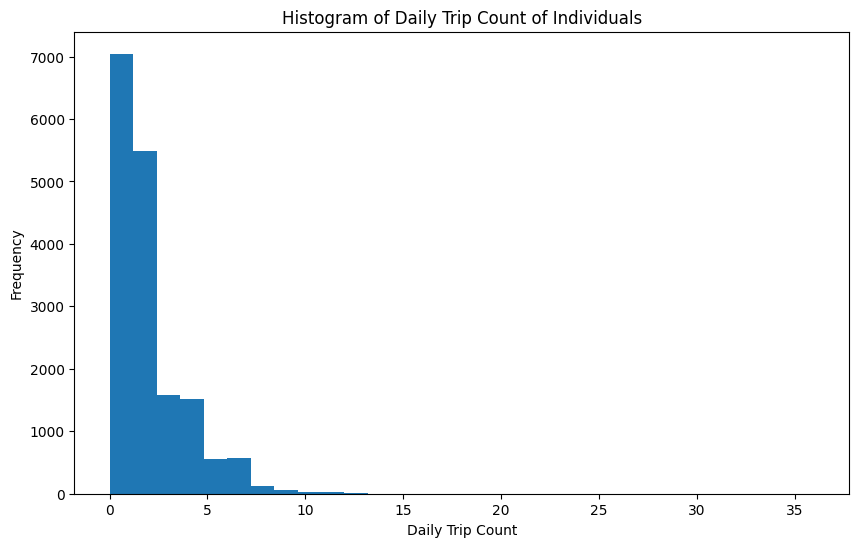

In [239]:

# Create a histogram to visualize the distribution of CNTTDTR

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display summary statistics
print("Summary statistics for CNTTDTR:", pp2['CNTTDTR'].describe(), sep="\n")

plt.figure(figsize=(10, 6))
plt.hist(pp2['CNTTDTR'].dropna(), bins=30)  # Using dropna() to ensure no NaN values
plt.title('Histogram of Daily Trip Count of Individuals')
plt.xlabel('Daily Trip Count')
plt.ylabel('Frequency')
plt.show()




In [240]:
# %pip install --upgrade --force-reinstall matplotlib


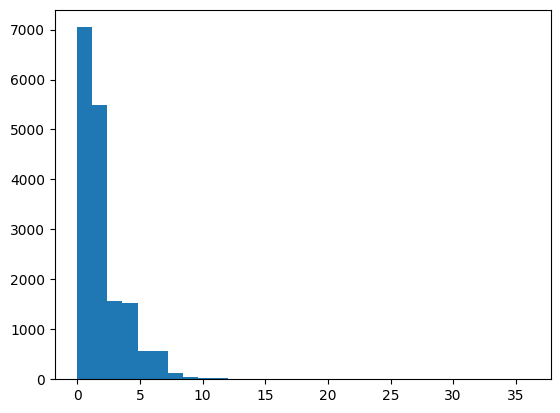

In [241]:
plt.hist(pp2['CNTTDTR'], bins=30)  # Using matplotlib's hist function directly
plt.show()


In [242]:
#  pp2 is  original DataFrame

# List of variables to be included in the new DataFrame
#URBRUR
variables = [
    'CNTTDTR', 'HHFAMINC_IMP', 'HHSIZE', 'HHVEHCNT', 'EDUC', 'HOMEOWN', 'SCHOOL1', 
    'MEDCOND', 'MSACAT', 'NUMADLT', 'R_SEX_IMP', 'R_RACE_IMP','HH_HISP', 'URBAN', 'URBANSIZE', 
    'WORKER', 'WRKCOUNT', 'DRVRCNT', 'WTPERFIN','DRIVER','HOMETYPE',
    'PPT517','YOUNGCHILD','LIF_CYC','CENSUS_R','TRAVDAY','TDAYDATE',
    'R_AGE','HOUSEID','PERSONID','uid'
]

# Create the new DataFrame pp3 with only the selected variables
pp3 = pp2[variables].copy()

# Display the first few rows of the new DataFrame
print(pp3.head())


   CNTTDTR  HHFAMINC_IMP  HHSIZE  HHVEHCNT  EDUC  HOMEOWN  SCHOOL1  MEDCOND  \
0        2            11       4         2     7        1        2        2   
1        3            11       4         2     7        1        2        2   
2        0            11       4         2    -1        1        1        2   
3        2            11       4         2    -1        1        1        2   
4        3             7       2         1     6        3        2        1   

   MSACAT  NUMADLT  ...  PPT517  YOUNGCHILD  LIF_CYC  CENSUS_R  TRAVDAY  \
0       1        2  ...       2           0        4         1        1   
1       1        2  ...       2           0        4         1        1   
2       1        2  ...       2           0        4         1        1   
3       1        2  ...       2           0        4         1        1   
4       3        2  ...       0           0        2         1        4   

   TDAYDATE  R_AGE     HOUSEID  PERSONID          uid  
0    202202     39

In [243]:
pp3['uid'].unique()

array(['90000130021', '90000130022', '90000130023', ..., '90002180342',
       '90002180361', '90002180401'], dtype=object)

In [244]:
# # Check if there are any duplicate values in the 'CATEGORY' column
# has_duplicates = pp3['uid'].duplicated().any()

# if has_duplicates:
#     print("There are duplicate values in the 'CATEGORY' column.")
# else:
#     print("All values in the 'CATEGORY' column are unique.")


In [245]:
pp3.dtypes

CNTTDTR           int64
HHFAMINC_IMP      int64
HHSIZE            int64
HHVEHCNT          int64
EDUC              int64
HOMEOWN           int64
SCHOOL1           int64
MEDCOND           int64
MSACAT            int64
NUMADLT           int64
R_SEX_IMP         int64
R_RACE_IMP        int64
HH_HISP           int64
URBAN             int64
URBANSIZE         int64
WORKER            int64
WRKCOUNT          int64
DRVRCNT           int64
WTPERFIN        float64
DRIVER            int64
HOMETYPE          int64
PPT517            int64
YOUNGCHILD        int64
LIF_CYC           int64
CENSUS_R          int64
TRAVDAY           int64
TDAYDATE          int64
R_AGE             int64
HOUSEID           int64
PERSONID          int64
uid              object
dtype: object

In [246]:
#  'R_SEX_IMP': {
# #     1: 'Male',
# #     2: 'Female'
# #     },

In [247]:
# pp4=pp3.copy()
# pp4['R_SEX_IMP']=pd.Categorical(pp3['R_SEX_IMP'].map({1: 'Male', 2: 'Female'}))

In [248]:
pp3['WORKER']

0        2
1        1
2       -1
3       -1
4        1
        ..
16992    2
16993    2
16994    2
16995    2
16996    1
Name: WORKER, Length: 16997, dtype: int64

In [249]:
# Assuming pp3 is your original DataFrame
pp4 = pp3.copy()

In [250]:
import pandas as pd



# Mapping and converting to categorical variables individually
pp4['R_SEX_IMP'] = pd.Categorical(pp3['R_SEX_IMP'].map({1: 'Male', 2: 'Female'}))

pp4['HHFAMINC_IMP'] = pd.Categorical(pp3['HHFAMINC_IMP'].map({
    1: 'Less than $10,000',
    2: '$10,000 to $14,999',
    3: '$15,000 to $24,999',
    4: '$25,000 to $34,999',
    5: '$35,000 to $49,999',
    6: '$50,000 to $74,999',
    7: '$75,000 to $99,999',
    8: '$100,000 to $124,999',
    9: '$125,000 to $149,999',
    10: '$150,000 to $199,999',
    11: '$200,000 or more'
}))

pp4['EDUC'] = pd.Categorical(pp3['EDUC'].map({
    -1: 'Valid skip',
    1: 'Less than high school',
    2: 'Some high school, no diploma/GED',
    3: 'High school graduate, have diploma/GED',
    4: 'Some college, no degree/ some trade school',
    5: 'Associates degree (2-year)/ trade school certificate',
    6: 'Bachelor’s degree',
    7: 'Master’s degree',
    8: 'Professional/Doctorate degree'
}))

pp4['MEDCOND'] = pd.Categorical(pp3['MEDCOND'].map({
    -7: 'I prefer not to answer',
    -8: 'Don’t know',
    -9: 'Not ascertained',
    1: 'Yes',
    2: 'No'
}))

pp4['HOMEOWN'] = pd.Categorical(pp3['HOMEOWN'].map({
    1: 'Owned by hh member with mortgage or loan',
    2: 'Owned by hh member free and clear (no mortgage)',
    3: 'Rented by hh member',
    4: 'Occupied without payment'
}))

pp4['MSACAT'] = pd.Categorical(pp3['MSACAT'].map({
    1: 'MSA of 1 million or more, with rail',
    2: 'MSA of 1 million or more, without rail',
    3: 'MSA less than 1 million',
    4: 'Not in MSA'
}))

pp4['URBAN'] = pd.Categorical(pp3['URBAN'].map({
    1: 'In an urban area',
    2: 'In an Urban cluster',
    3: 'In an area surrounded by urban areas',
    4: 'Not in urban area'
}))

pp4['URBANSIZE'] = pd.Categorical(pp3['URBANSIZE'].map({
    1: '50,000-199,999',
    2: '200,000-499,999',
    3: '500,000-999,999',
    4: '1,000,000 or more with heavy rail',
    5: '1,000,000 or more without heavy rail',
    6: 'Not in urbanized area'
}))

pp4['WORKER'] = pd.Categorical(pp3['WORKER'].map({
    -1: 'Valid skip',
    1: 'Worker',
    2: 'Not worker'
}))

pp4['R_RACE_IMP'] = pd.Categorical(pp3['R_RACE_IMP'].map({
    1: 'White',
    2: 'Black or African American',
    3: 'Asian',
    4: 'American Indian/Alaska Native',
    5: 'Native Hawaiian/Pacific Islander',
    6: 'Multiple races selected',
    97: 'Other race'
}))

pp4['TRAVDAY'] = pd.Categorical(pp3['TRAVDAY'].map({
    1: 'Sunday',
    2: 'Monday',
    3: 'Tuesday',
    4: 'Wednesday',
    5: 'Thursday',
    6: 'Friday',
    7: 'Saturday'
}))

pp4['TDAYDATE'] = pd.Categorical(pp3['TDAYDATE'].map({
    202201: 'Jan 2022',
    202202: 'Feb 2022',
    202203: 'Mar 2022',
    202204: 'Apr 2022',
    202205: 'May 2022',
    202206: 'Jun 2022',
    202207: 'Jul 2022',
    202208: 'Aug 2022',
    202209: 'Sep 2022',
    202210: 'Oct 2022',
    202211: 'Nov 2022',
    202212: 'Dec 2022',
    202301: 'Jan 2023'
}))

pp4['LIF_CYC'] = pd.Categorical(pp3['LIF_CYC'].map({
    1: 'one adult, no children',
    2: '2+ adults, no children',
    3: 'one adult, youngest child 0-5',
    4: '2+ adults, youngest child 0-5',
    5: 'one adult, youngest child 6-15',
    6: '2+ adults, youngest child 6-15',
    7: 'one adult, youngest child 16-21',
    8: '2+ adults, youngest child 16-21',
    9: 'one adult, retired, no children',
    10: '2+ adults, retired, no children'
}))

pp4['CENSUS_R'] = pd.Categorical(pp3['CENSUS_R'].map({
    1: 'Northeast',
    2: 'Midwest',
    3: 'South',
    4: 'West'
}))

pp4['SCHOOL1'] = pd.Categorical(pp3['SCHOOL1'].map({
    -9: 'Not ascertained',
    1: 'Yes',
    2: 'No'
}))

pp4['HH_HISP'] = pd.Categorical(pp3['HH_HISP'].map({
    1: 'Hispanic or Latino',
    2: 'Not Hispanic or Latino'
}))

pp4['DRIVER'] = pd.Categorical(pp3['DRIVER'].map({
    -1: 'Valid skip',
    1: 'Yes',
    2: 'No'
}))

pp4['HOMETYPE'] = pd.Categorical(pp3['HOMETYPE'].map({
    1: 'One-family detached',
    2: 'One-family attached (townhome, condo)',
    3: 'Building with 2 or more apartments',
    4: 'Mobile home',
    5: 'Boat, RV, van, etc.'
}))


In [251]:
pp5=pp4.copy()

In [252]:
pp5

,CNTTDTR,HHFAMINC_IMP,HHSIZE,HHVEHCNT,EDUC,HOMEOWN,SCHOOL1,MEDCOND,MSACAT,NUMADLT,...,PPT517,YOUNGCHILD,LIF_CYC,CENSUS_R,TRAVDAY,TDAYDATE,R_AGE,HOUSEID,PERSONID,uid
0,2,"$200,000 or more",4,2,Master’s degree,Owned by hh member with mortgage or loan,No,No,"MSA of 1 million or more, with rail",2,...,2,0,"2+ adults, youngest child 0-5",Northeast,Sunday,Feb 2022,39,9000013002,1,90000130021
1,3,"$200,000 or more",4,2,Master’s degree,Owned by hh member with mortgage or loan,No,No,"MSA of 1 million or more, with rail",2,...,2,0,"2+ adults, youngest child 0-5",Northeast,Sunday,Feb 2022,42,9000013002,2,90000130022
2,0,"$200,000 or more",4,2,Valid skip,Owned by hh member with mortgage or loan,Yes,No,"MSA of 1 million or more, with rail",2,...,2,0,"2+ adults, youngest child 0-5",Northeast,Sunday,Feb 2022,8,9000013002,3,90000130023
3,2,"$200,000 or more",4,2,Valid skip,Owned by hh member with mortgage or loan,Yes,No,"MSA of 1 million or more, with rail",2,...,2,0,"2+ adults, youngest child 0-5",Northeast,Sunday,Feb 2022,5,9000013002,4,90000130024
4,3,"$75,000 to $99,999",2,1,Bachelor’s degree,Rented by hh member,No,Yes,MSA less than 1 million,2,...,0,0,"2+ adults, no children",Northeast,Wednesday,Feb 2022,32,9000013016,1,90000130161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16992,0,"$25,000 to $34,999",1,1,Bachelor’s degree,Owned by hh member free and clear (no mortgage),No,No,MSA less than 1 million,1,...,0,0,"one adult, retired, no children",South,Sunday,Dec 2022,74,9000218021,1,90002180211
16993,0,"$25,000 to $34,999",2,2,"Some high school, no diploma/GED",Owned by hh member free and clear (no mortgage),No,No,Not in MSA,2,...,0,0,"2+ adults, retired, no children",South,Thursday,Dec 2022,60,9000218034,1,90002180341
16994,0,"$25,000 to $34,999",2,2,Less than high school,Owned by hh member free and clear (no mortgage),No,No,Not in MSA,2,...,0,0,"2+ adults, retired, no children",South,Thursday,Dec 2022,62,9000218034,2,90002180342
16995,0,"$10,000 to $14,999",1,0,Less than high school,Rented by hh member,No,Yes,Not in MSA,1,...,0,0,"one adult, no children",South,Wednesday,Jan 2023,42,9000218036,1,90002180361


In [253]:
print(pp5)

       CNTTDTR        HHFAMINC_IMP  HHSIZE  HHVEHCNT  \
0            2    $200,000 or more       4         2   
1            3    $200,000 or more       4         2   
2            0    $200,000 or more       4         2   
3            2    $200,000 or more       4         2   
4            3  $75,000 to $99,999       2         1   
...        ...                 ...     ...       ...   
16992        0  $25,000 to $34,999       1         1   
16993        0  $25,000 to $34,999       2         2   
16994        0  $25,000 to $34,999       2         2   
16995        0  $10,000 to $14,999       1         0   
16996        3  $50,000 to $74,999       1         1   

                                             EDUC  \
0                                 Master’s degree   
1                                 Master’s degree   
2                                      Valid skip   
3                                      Valid skip   
4                               Bachelor’s degree   
...      

In [254]:
# # Define the path where you want to save the Excel file
# output_excel_path = 'I:\\PHD Utah state uni\\Trip Generation for people with disablity\\Pouyan Files and reports with Dr Singleton\\Code\\dd.xlsx'

# # Save the DataFrame to an Excel file at the specified path
# pp5.to_excel(output_excel_path, index=False)

# print(f"File saved to {output_excel_path}")

In [255]:
pp5.dtypes

CNTTDTR            int64
HHFAMINC_IMP    category
HHSIZE             int64
HHVEHCNT           int64
EDUC            category
HOMEOWN         category
SCHOOL1         category
MEDCOND         category
MSACAT          category
NUMADLT            int64
R_SEX_IMP       category
R_RACE_IMP      category
HH_HISP         category
URBAN           category
URBANSIZE       category
WORKER          category
WRKCOUNT           int64
DRVRCNT            int64
WTPERFIN         float64
DRIVER          category
HOMETYPE        category
PPT517             int64
YOUNGCHILD         int64
LIF_CYC         category
CENSUS_R        category
TRAVDAY         category
TDAYDATE        category
R_AGE              int64
HOUSEID            int64
PERSONID           int64
uid               object
dtype: object

In [256]:
pp5['HHFAMINC_IMP'].unique()

['$200,000 or more', '$75,000 to $99,999', '$150,000 to $199,999', '$50,000 to $74,999', '$10,000 to $14,999', ..., '$100,000 to $124,999', '$25,000 to $34,999', '$125,000 to $149,999', '$15,000 to $24,999', 'Less than $10,000']
Length: 11
Categories (11, object): ['$10,000 to $14,999', '$100,000 to $124,999', '$125,000 to $149,999', '$15,000 to $24,999', ..., '$35,000 to $49,999', '$50,000 to $74,999', '$75,000 to $99,999', 'Less than $10,000']

In [257]:
pp6=pp5.copy()

In [258]:
pp6['CNTTDTR'].unique()

array([ 2,  3,  0,  1,  5,  4,  7,  8, 12,  6,  9, 15, 10, 11, 13, 36, 14,
       22], dtype=int64)

In [259]:
#Condensed variables such as hhincome and educ
# Mapping of original income ranges to new categories
hh_income_mapping = {
    '$10,000 to $14,999': 'Low', 'Less than $10,000': 'Low',
    '$15,000 to $24,999': 'Low', '$25,000 to $34,999': 'Low', '$35,000 to $49,999': 'Medium',
    '$50,000 to $74,999': 'Medium', '$75,000 to $99,999': 'High', '$100,000 to $124,999': 'High',
    '$125,000 to $149,999': 'Very High', '$150,000 to $199,999': 'Very High', '$200,000 or more': 'Very High'
}

# Recategorize 'HHFAMINC' and handle NaNs
pp6['HHINC_4Cat'] = pp5['HHFAMINC_IMP'].map(hh_income_mapping).astype('category')

# This adds the 'Income_Category' column to the dataframe with the income recategorized.
#pp6['EDUC'].unique()
# array(['Very High', 'High', 'Medium', 'Low'], dtype=object)



# Define the mapping of original categories to the new six categories
educ_mapping = {
    'Some high school, no diploma/GED': 'Some high school',
    'High school graduate, have diploma/GED': 'Some high school',
    'Some college, no degree/ some trade school': 'Some college',
    'Associates degree (2-year)/ trade school certificate': 'Associates/Bachelor’s degree',
    'Bachelor’s degree': 'Associates/Bachelor’s degree',
    'Master’s degree': 'Graduate Degree',
    'Professional/Doctorate degree': 'Graduate Degree',
    'Less than high school': 'Less than high school',
    'Valid skip': 'Valid skip'
}

# Apply the mapping to create a new categorized column
pp6['EDUC_6cat'] = pp6['EDUC'].map(educ_mapping).astype('category')

# This code will transform the 'EDUC' column values into one of the six new categories
#pp6['EDUC_6cat'].unique() 
#array(['Graduate Degree', 'Valid skip', 'Associates/Bachelor’s degree',
#        'Some college', 'Some high school', 'Less than high school'],
#       dtype=object)


In [260]:
# Recategorizing 'CNTTDTR' to ordered categories suitable for an ordered probit model
pp6['CNTTDTR_cat_ordered'] = pp6['CNTTDTR'].apply(lambda value: 'zero' if value == 0 else 'one' if value == 1 else 'two' if value == 2 else 'three' if value == 3 else 'four_plus').astype(pd.CategoricalDtype(categories=['zero', 'one', 'two', 'three', 'four_plus'], ordered=True))
#pp6['CNTTDTR_cat_ordered'] = pp6['CNTTDTR_cat_ordered'].astype(pd.CategoricalDtype(categories=['zero', 'one', 'two', 'three', 'four_plus'], ordered=True)
# Verify the operation by displaying the unique ordered categories of the new 'CNTTDTR_cat_ordered' column
pp6['CNTTDTR_cat_ordered'].unique()


['two', 'three', 'zero', 'one', 'four_plus']
Categories (5, object): ['zero' < 'one' < 'two' < 'three' < 'four_plus']

In [261]:
pp6['EDUC_6cat'].unique()

['Graduate Degree', 'Valid skip', 'Associates/Bachelor’s degree', 'Some college', 'Some high school', 'Less than high school']
Categories (6, object): ['Associates/Bachelor’s degree', 'Graduate Degree', 'Less than high school', 'Some college', 'Some high school', 'Valid skip']

In [262]:
pp6.dtypes

CNTTDTR                   int64
HHFAMINC_IMP           category
HHSIZE                    int64
HHVEHCNT                  int64
EDUC                   category
HOMEOWN                category
SCHOOL1                category
MEDCOND                category
MSACAT                 category
NUMADLT                   int64
R_SEX_IMP              category
R_RACE_IMP             category
HH_HISP                category
URBAN                  category
URBANSIZE              category
WORKER                 category
WRKCOUNT                  int64
DRVRCNT                   int64
WTPERFIN                float64
DRIVER                 category
HOMETYPE               category
PPT517                    int64
YOUNGCHILD                int64
LIF_CYC                category
CENSUS_R               category
TRAVDAY                category
TDAYDATE               category
R_AGE                     int64
HOUSEID                   int64
PERSONID                  int64
uid                      object
HHINC_4C

In [263]:
# m_var=['CNTTDTR', 'HHSIZE', 'HHVEHCNT', 'HOMEOWN', 'SCHOOL1', 'MEDCOND',
#   'MSACAT', 'NUMADLT', 'R_SEX_IMP', 'R_RACE_IMP', 'HH_HISP', 'URBAN', 'URBANSIZE', 'WORKER',
#     'WRKCOUNT', 'DRVRCNT', 'WTPERFIN', 'DRIVER', 'HOMETYPE', 'PPT517', 'YOUNGCHILD', 'LIF_CYC',
#       'CENSUS_R', 'TRAVDAY', 'TDAYDATE', 'HHINC_4Cat', 'EDUC_6cat','HOUSEID','PERSONID']
indep_var=pp6[['HHSIZE', 'HHVEHCNT', 'HOMEOWN', 'SCHOOL1', 'MEDCOND',
  'MSACAT', 'NUMADLT', 'R_SEX_IMP', 'R_RACE_IMP', 'HH_HISP', 'URBAN', 'URBANSIZE', 'WORKER',
    'WRKCOUNT', 'DRVRCNT', 'DRIVER', 'HOMETYPE', 'PPT517', 'YOUNGCHILD', 'LIF_CYC',
      'CENSUS_R', 'HHINC_4Cat', 'EDUC_6cat']]
weight_var=pp6[['WTPERFIN']]
dep_var=pp6[['CNTTDTR']]
dep_var_cat=[['CNTTDTR_cat_ordered']]


In [264]:
pp7=pp6[['CNTTDTR', 'HHSIZE', 'HHVEHCNT', 'HOMEOWN', 'SCHOOL1', 'MEDCOND', 'R_AGE',
  'MSACAT', 'NUMADLT', 'R_SEX_IMP', 'R_RACE_IMP', 'HH_HISP', 'URBAN', 'URBANSIZE', 'WORKER',
    'WRKCOUNT', 'DRVRCNT', 'WTPERFIN', 'DRIVER', 'HOMETYPE', 'PPT517', 'YOUNGCHILD', 'LIF_CYC',
      'CENSUS_R', 'TRAVDAY', 'TDAYDATE', 'HHINC_4Cat', 'EDUC_6cat','HOUSEID','PERSONID','uid']]

In [265]:
pp7['MEDCOND'].unique()

['No', 'Yes', 'Don’t know', 'I prefer not to answer', 'Not ascertained']
Categories (5, object): ['Don’t know', 'I prefer not to answer', 'No', 'Not ascertained', 'Yes']

In [266]:
# #Filter PWDs
# dis = pp7[pp7['MEDCOND'] == 'Yes']
# print(dis)


In [267]:
pp7.head()

,CNTTDTR,HHSIZE,HHVEHCNT,HOMEOWN,SCHOOL1,MEDCOND,R_AGE,MSACAT,NUMADLT,R_SEX_IMP,...,YOUNGCHILD,LIF_CYC,CENSUS_R,TRAVDAY,TDAYDATE,HHINC_4Cat,EDUC_6cat,HOUSEID,PERSONID,uid
0,2,4,2,Owned by hh member with mortgage or loan,No,No,39,"MSA of 1 million or more, with rail",2,Female,...,0,"2+ adults, youngest child 0-5",Northeast,Sunday,Feb 2022,Very High,Graduate Degree,9000013002,1,90000130021
1,3,4,2,Owned by hh member with mortgage or loan,No,No,42,"MSA of 1 million or more, with rail",2,Male,...,0,"2+ adults, youngest child 0-5",Northeast,Sunday,Feb 2022,Very High,Graduate Degree,9000013002,2,90000130022
2,0,4,2,Owned by hh member with mortgage or loan,Yes,No,8,"MSA of 1 million or more, with rail",2,Male,...,0,"2+ adults, youngest child 0-5",Northeast,Sunday,Feb 2022,Very High,Valid skip,9000013002,3,90000130023
3,2,4,2,Owned by hh member with mortgage or loan,Yes,No,5,"MSA of 1 million or more, with rail",2,Male,...,0,"2+ adults, youngest child 0-5",Northeast,Sunday,Feb 2022,Very High,Valid skip,9000013002,4,90000130024
4,3,2,1,Rented by hh member,No,Yes,32,MSA less than 1 million,2,Female,...,0,"2+ adults, no children",Northeast,Wednesday,Feb 2022,High,Associates/Bachelor’s degree,9000013016,1,90000130161


In [268]:
tt.head()

,HOUSEID,PERSONID,TRIPID,SEQ_TRIPID,VEHCASEID,FRSTHM,PARK,HHMEMDRV,TDWKND,TRAVDAY,...,WORKER,DRIVER,R_RACE,R_HISP,PROXY,EDUC,PRMACT,R_SEX_IMP,VEHTYPE,uid
0,9000013002,1,1,1,900001300201,1,2,1,1,1,...,2,1,1,2,1,7,3,2,3,90000130021
1,9000013002,1,2,2,900001300201,1,2,1,1,1,...,2,1,1,2,1,7,3,2,3,90000130021
2,9000013002,2,1,1,900001300202,1,-1,1,1,1,...,1,1,1,2,2,7,-1,1,3,90000130022
3,9000013002,2,2,2,900001300202,1,-1,1,1,1,...,1,1,1,2,2,7,-1,1,3,90000130022
4,9000013002,2,3,3,900001300202,1,-1,1,1,1,...,1,1,1,2,2,7,-1,1,3,90000130022


In [269]:
#Add Trip distance and Trip duration for each person with unique person id
# Grouping the 'tt' DataFrame by 'PERSONID' and calculating the sum of 'TRPMILES' and 'TRIPDURATION'
trip_dis_dur = tt.groupby('uid').agg({'TRPMILES': 'sum', 'TRVLCMIN': 'sum'}).reset_index()

# Renaming the aggregated columns for clarity
trip_dis_dur.rename(columns={'TRPMILES': 'Total_TRPMILES', 'TRVLCMIN': 'Total_TRVLCMIN'}, inplace=True)

# Merging the aggregated data back into the 'pp7' DataFrame based on 'PERSONID'
pp8 = pd.merge(pp7, trip_dis_dur, on='uid', how='left')

In [270]:
pp8.head()

,CNTTDTR,HHSIZE,HHVEHCNT,HOMEOWN,SCHOOL1,MEDCOND,R_AGE,MSACAT,NUMADLT,R_SEX_IMP,...,CENSUS_R,TRAVDAY,TDAYDATE,HHINC_4Cat,EDUC_6cat,HOUSEID,PERSONID,uid,Total_TRPMILES,Total_TRVLCMIN
0,2,4,2,Owned by hh member with mortgage or loan,No,No,39,"MSA of 1 million or more, with rail",2,Female,...,Northeast,Sunday,Feb 2022,Very High,Graduate Degree,9000013002,1,90000130021,7.804848,25.0
1,3,4,2,Owned by hh member with mortgage or loan,No,No,42,"MSA of 1 million or more, with rail",2,Male,...,Northeast,Sunday,Feb 2022,Very High,Graduate Degree,9000013002,2,90000130022,35.924177,70.0
2,0,4,2,Owned by hh member with mortgage or loan,Yes,No,8,"MSA of 1 million or more, with rail",2,Male,...,Northeast,Sunday,Feb 2022,Very High,Valid skip,9000013002,3,90000130023,NaN,NaN
3,2,4,2,Owned by hh member with mortgage or loan,Yes,No,5,"MSA of 1 million or more, with rail",2,Male,...,Northeast,Sunday,Feb 2022,Very High,Valid skip,9000013002,4,90000130024,7.804848,25.0
4,3,2,1,Rented by hh member,No,Yes,32,MSA less than 1 million,2,Female,...,Northeast,Wednesday,Feb 2022,High,Associates/Bachelor’s degree,9000013016,1,90000130161,10.933499,55.0


In [271]:
pp8

,CNTTDTR,HHSIZE,HHVEHCNT,HOMEOWN,SCHOOL1,MEDCOND,R_AGE,MSACAT,NUMADLT,R_SEX_IMP,...,CENSUS_R,TRAVDAY,TDAYDATE,HHINC_4Cat,EDUC_6cat,HOUSEID,PERSONID,uid,Total_TRPMILES,Total_TRVLCMIN
0,2,4,2,Owned by hh member with mortgage or loan,No,No,39,"MSA of 1 million or more, with rail",2,Female,...,Northeast,Sunday,Feb 2022,Very High,Graduate Degree,9000013002,1,90000130021,7.804848,25.0
1,3,4,2,Owned by hh member with mortgage or loan,No,No,42,"MSA of 1 million or more, with rail",2,Male,...,Northeast,Sunday,Feb 2022,Very High,Graduate Degree,9000013002,2,90000130022,35.924177,70.0
2,0,4,2,Owned by hh member with mortgage or loan,Yes,No,8,"MSA of 1 million or more, with rail",2,Male,...,Northeast,Sunday,Feb 2022,Very High,Valid skip,9000013002,3,90000130023,NaN,NaN
3,2,4,2,Owned by hh member with mortgage or loan,Yes,No,5,"MSA of 1 million or more, with rail",2,Male,...,Northeast,Sunday,Feb 2022,Very High,Valid skip,9000013002,4,90000130024,7.804848,25.0
4,3,2,1,Rented by hh member,No,Yes,32,MSA less than 1 million,2,Female,...,Northeast,Wednesday,Feb 2022,High,Associates/Bachelor’s degree,9000013016,1,90000130161,10.933499,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16992,0,1,1,Owned by hh member free and clear (no mortgage),No,No,74,MSA less than 1 million,1,Female,...,South,Sunday,Dec 2022,Low,Associates/Bachelor’s degree,9000218021,1,90002180211,NaN,NaN
16993,0,2,2,Owned by hh member free and clear (no mortgage),No,No,60,Not in MSA,2,Female,...,South,Thursday,Dec 2022,Low,Some high school,9000218034,1,90002180341,NaN,NaN
16994,0,2,2,Owned by hh member free and clear (no mortgage),No,No,62,Not in MSA,2,Male,...,South,Thursday,Dec 2022,Low,Less than high school,9000218034,2,90002180342,NaN,NaN
16995,0,1,0,Rented by hh member,No,Yes,42,Not in MSA,1,Female,...,South,Wednesday,Jan 2023,Low,Less than high school,9000218036,1,90002180361,NaN,NaN


In [272]:
pp8[['CNTTDTR','uid','Total_TRPMILES','Total_TRVLCMIN']]


,CNTTDTR,uid,Total_TRPMILES,Total_TRVLCMIN
0,2,90000130021,7.804848,25.0
1,3,90000130022,35.924177,70.0
2,0,90000130023,NaN,NaN
3,2,90000130024,7.804848,25.0
4,3,90000130161,10.933499,55.0
...,...,...,...,...
16992,0,90002180211,NaN,NaN
16993,0,90002180341,NaN,NaN
16994,0,90002180342,NaN,NaN
16995,0,90002180361,NaN,NaN


In [273]:
# Checking the condition
# For rows where CNTTDTR is 0, check if Total_TRPMILES and Total_TRVLCMIN are NaN
# Select rows where CNTTDTR is 0
cnttdtr_zero = pp8['CNTTDTR'] == 0
# Check if both Total_TRPMILES and Total_TRVLCMIN are NaN for these rows
conditions_met = pp8[cnttdtr_zero].apply(lambda row: pd.isna(row['Total_TRPMILES']) and pd.isna(row['Total_TRVLCMIN']), axis=1)

# Result
print(conditions_met)

2        True
6        True
8        True
9        True
10       True
         ... 
16991    True
16992    True
16993    True
16994    True
16995    True
Length: 6405, dtype: bool


In [274]:
# Replace NaN with 0 for Total_TRPMILES and Total_TRVLCMIN when CNTTDTR is 0
pp8.loc[(pp8['CNTTDTR'] == 0) & pd.isna(pp8['Total_TRPMILES']), 'Total_TRPMILES'] = 0
pp8.loc[(pp8['CNTTDTR'] == 0) & pd.isna(pp8['Total_TRVLCMIN']), 'Total_TRVLCMIN'] = 0


In [275]:
cnttdtr_zero = pp8['CNTTDTR'] == 0
pp8[['CNTTDTR','uid','Total_TRPMILES','Total_TRVLCMIN']]

,CNTTDTR,uid,Total_TRPMILES,Total_TRVLCMIN
0,2,90000130021,7.804848,25.0
1,3,90000130022,35.924177,70.0
2,0,90000130023,0.000000,0.0
3,2,90000130024,7.804848,25.0
4,3,90000130161,10.933499,55.0
...,...,...,...,...
16992,0,90002180211,0.000000,0.0
16993,0,90002180341,0.000000,0.0
16994,0,90002180342,0.000000,0.0
16995,0,90002180361,0.000000,0.0


In [276]:
print(tt['WHYTRP1S'].unique())


[50  1 80 30 40 70 20 10 97]


In [277]:
# map the level of Trip purpose
# Mapping levels of tt['WHYTRP1S'] to descriptive categories
tt['Trip_purpose'] = tt['WHYTRP1S'].map({
    1: 'Home',
    10: 'Work',
    20: 'School/Daycare/Religious',
    30: 'Medical/Dental_services',
    40: 'Shopping/Errands',
    50: 'Social/Recreational',
    70: 'Transport_somebody',
    80: 'Meals',
    97: 'Sth_else'
})

tt['Trip_purpose'] = pd.Categorical(tt['Trip_purpose'])

# Display the DataFrame to verify the changes (optional)
print(tt[['WHYTRP1S', 'Trip_purpose']])


       WHYTRP1S         Trip_purpose
0            50  Social/Recreational
1             1                 Home
2            80                Meals
3            80                Meals
4             1                 Home
...         ...                  ...
31069        40     Shopping/Errands
31070         1                 Home
31071        40     Shopping/Errands
31072         1                 Home
31073        40     Shopping/Errands

[31074 rows x 2 columns]


In [278]:
tt['Trip_purpose'].unique()

['Social/Recreational', 'Home', 'Meals', 'Medical/Dental_services', 'Shopping/Errands', 'Transport_somebody', 'School/Daycare/Religious', 'Work', 'Sth_else']
Categories (9, object): ['Home', 'Meals', 'Medical/Dental_services', 'School/Daycare/Religious', ..., 'Social/Recreational', 'Sth_else', 'Transport_somebody', 'Work']

In [279]:
#adding new columns to the pp9 DataFrame that show the count of specific trip purposes for each person

import pandas as pd

# Group by 'uid' and 'Trip_purpose' and count the occurrences, then unstack
trip_purpose_counts = tt.groupby(['uid', 'Trip_purpose']).size().unstack(fill_value=0)

# Reset index if you need 'uid' as a column (for merging purposes)
trip_purpose_counts.reset_index(inplace=True)

# Merge the trip purpose counts with the pp8 DataFrame
pp9 = pd.merge(pp8, trip_purpose_counts, on='uid', how='left')

# Fill NaN values with 0s for the newly added columns (trip purposes)
for col in trip_purpose_counts.columns[1:]:  # Skip 'uid' column
    pp9[col] = pp9[col].fillna(0).astype(int)

# Display the first few rows of the updated pp9 DataFrame to verify the changes
print(pp9.head())

   CNTTDTR  HHSIZE  HHVEHCNT                                   HOMEOWN  \
0        2       4         2  Owned by hh member with mortgage or loan   
1        3       4         2  Owned by hh member with mortgage or loan   
2        0       4         2  Owned by hh member with mortgage or loan   
3        2       4         2  Owned by hh member with mortgage or loan   
4        3       2         1                       Rented by hh member   

  SCHOOL1 MEDCOND  R_AGE                               MSACAT  NUMADLT  \
0      No      No     39  MSA of 1 million or more, with rail        2   
1      No      No     42  MSA of 1 million or more, with rail        2   
2     Yes      No      8  MSA of 1 million or more, with rail        2   
3     Yes      No      5  MSA of 1 million or more, with rail        2   
4      No     Yes     32              MSA less than 1 million        2   

  R_SEX_IMP  ... Total_TRVLCMIN Home Meals Medical/Dental_services  \
0    Female  ...           25.0    1    

C:\Users\pouyan\AppData\Local\Temp\ipykernel_9464\3998921365.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trip_purpose_counts = tt.groupby(['uid', 'Trip_purpose']).size().unstack(fill_value=0)


In [280]:
print(pp9.columns)

Index(['CNTTDTR', 'HHSIZE', 'HHVEHCNT', 'HOMEOWN', 'SCHOOL1', 'MEDCOND',
       'R_AGE', 'MSACAT', 'NUMADLT', 'R_SEX_IMP', 'R_RACE_IMP', 'HH_HISP',
       'URBAN', 'URBANSIZE', 'WORKER', 'WRKCOUNT', 'DRVRCNT', 'WTPERFIN',
       'DRIVER', 'HOMETYPE', 'PPT517', 'YOUNGCHILD', 'LIF_CYC', 'CENSUS_R',
       'TRAVDAY', 'TDAYDATE', 'HHINC_4Cat', 'EDUC_6cat', 'HOUSEID', 'PERSONID',
       'uid', 'Total_TRPMILES', 'Total_TRVLCMIN', 'Home', 'Meals',
       'Medical/Dental_services', 'School/Daycare/Religious',
       'Shopping/Errands', 'Social/Recreational', 'Sth_else',
       'Transport_somebody', 'Work'],
      dtype='object')


In [281]:
# # Define the path where you want to save the Excel file
# output_excel_path = 'I:\\PHD Utah state uni\\Trip Generation for people with disablity\\Pouyan Files and reports with Dr Singleton\\Code\\dd2.xlsx'

# # Save the DataFrame to an Excel file at the specified path
# pp9.to_excel(output_excel_path, index=False)

# print(f"File saved to {output_excel_path}")

In [282]:
pp9['MEDCOND'].unique()

['No', 'Yes', 'Don’t know', 'I prefer not to answer', 'Not ascertained']
Categories (5, object): ['Don’t know', 'I prefer not to answer', 'No', 'Not ascertained', 'Yes']

### Filter PWDs
#zz is a dataframe contain trip information of people with disabilities.
#ss is a dataframe contain trip information of people without disabilities.

In [283]:
#Filter PWDs
zz = pp9[pp9['MEDCOND'] == 'Yes']
print(zz)

       CNTTDTR  HHSIZE  HHVEHCNT  \
4            3       2         1   
19           0       2         2   
21           0       1         0   
53           0       4         2   
84           0       1         2   
...        ...     ...       ...   
16950        0       5         3   
16971        5       3         1   
16977        0       3         2   
16991        0       2         1   
16995        0       1         0   

                                               HOMEOWN SCHOOL1 MEDCOND  R_AGE  \
4                                  Rented by hh member      No     Yes     32   
19     Owned by hh member free and clear (no mortgage)      No     Yes     67   
21                                 Rented by hh member      No     Yes     40   
53            Owned by hh member with mortgage or loan      No     Yes     64   
84            Owned by hh member with mortgage or loan      No     Yes     61   
...                                                ...     ...     ...    ...   


In [284]:
# Filter rows where 'MEDCOND' is not 'Yes'
ss = pp9[pp9['MEDCOND'] != 'Yes']
print(ss)

       CNTTDTR  HHSIZE  HHVEHCNT  \
0            2       4         2   
1            3       4         2   
2            0       4         2   
3            2       4         2   
5            3       2         1   
...        ...     ...       ...   
16990        3       2         1   
16992        0       1         1   
16993        0       2         2   
16994        0       2         2   
16996        3       1         1   

                                               HOMEOWN SCHOOL1 MEDCOND  R_AGE  \
0             Owned by hh member with mortgage or loan      No      No     39   
1             Owned by hh member with mortgage or loan      No      No     42   
2             Owned by hh member with mortgage or loan     Yes      No      8   
3             Owned by hh member with mortgage or loan     Yes      No      5   
5                                  Rented by hh member      No      No     41   
...                                                ...     ...     ...    ...   


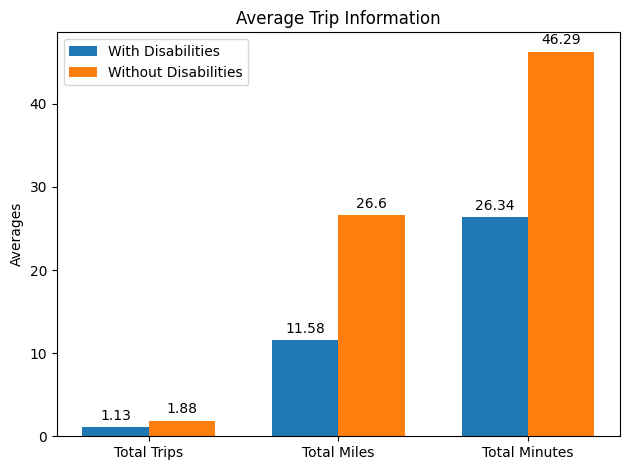

In [285]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the means
means_zz = zz[['CNTTDTR', 'Total_TRPMILES', 'Total_TRVLCMIN']].mean()
means_ss = ss[['CNTTDTR', 'Total_TRPMILES', 'Total_TRVLCMIN']].mean()

# Define the labels and positions
labels = ['Total Trips', 'Total Miles', 'Total Minutes']
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, means_zz, width, label='With Disabilities')
bars2 = ax.bar(x + width/2, means_ss, width, label='Without Disabilities')

# Add some text for labels, title, and custom x-axis tick labels, etc.
ax.set_ylabel('Averages')
ax.set_title('Average Trip Information')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add numerical labels above the bars for clarity
def autolabel(bars):
    """Attach a text label above each bar in *bars*, displaying its height."""
    for bar in bars:
        height = bar.get_height()
        ax.annotate('{}'.format(round(height, 2)),
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(bars1)
autolabel(bars2)

fig.tight_layout()

plt.show()


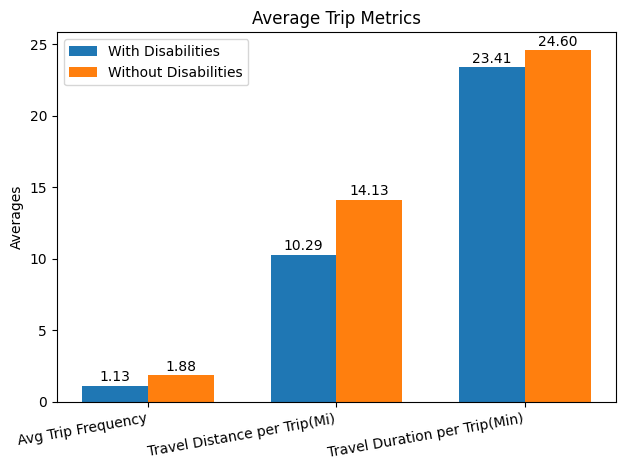

In [286]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming zz and ss are your datasets, calculate the average trip frequency
avg_trip_freq_zz = zz['CNTTDTR'].mean()
avg_trip_freq_ss = ss['CNTTDTR'].mean()

# Calculate average miles per trip and average minutes per trip
avg_miles_per_trip_zz = zz['Total_TRPMILES'].sum() / zz['CNTTDTR'].sum()
avg_miles_per_trip_ss = ss['Total_TRPMILES'].sum() / ss['CNTTDTR'].sum()

avg_minutes_per_trip_zz = zz['Total_TRVLCMIN'].sum() / zz['CNTTDTR'].sum()
avg_minutes_per_trip_ss = ss['Total_TRVLCMIN'].sum() / ss['CNTTDTR'].sum()

# Combine these averages into numpy arrays for plotting
means_zz = np.array([avg_trip_freq_zz, avg_miles_per_trip_zz, avg_minutes_per_trip_zz])
means_ss = np.array([avg_trip_freq_ss, avg_miles_per_trip_ss, avg_minutes_per_trip_ss])

# Define the labels and positions
labels = ['Avg Trip Frequency', 'Travel Distance per Trip(Mi)', 'Travel Duration per Trip(Min)']
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
bars1 = ax.bar(x - width/2, means_zz, width, label='With Disabilities')
bars2 = ax.bar(x + width/2, means_ss, width, label='Without Disabilities')

# Add some text for labels, title, and custom x-axis tick labels, etc.
ax.set_ylabel('Averages')
ax.set_title('Average Trip Metrics')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=10, ha='right')
ax.legend()

# Add numerical labels above the bars for clarity
def autolabel(bars):
    """Attach a text label above each bar in *bars*, displaying its height."""
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 1),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(bars1)
autolabel(bars2)

fig.tight_layout()

plt.show()


## Mann-Whitney U test

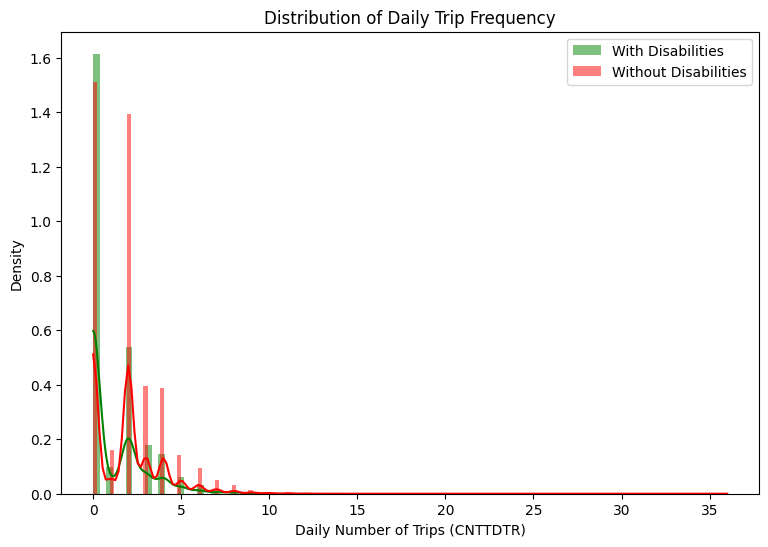

In [287]:
import seaborn as sns
import matplotlib.pyplot as plt

# Setting up the matplotlib figure
plt.figure(figsize=(9, 6))

# Plotting the distribution of daily trip frequency for people with disabilities
sns.histplot(zz['CNTTDTR'], color="green", label='With Disabilities', kde=True, stat="density", linewidth=0)

# Plotting the distribution of daily trip frequency for people without disabilities
sns.histplot(ss['CNTTDTR'], color="red", label='Without Disabilities', kde=True, stat="density", linewidth=0)

plt.xlabel('Daily Number of Trips (CNTTDTR)')
plt.ylabel('Density')
plt.title('Distribution of Daily Trip Frequency')
plt.legend()

plt.show()

    data_with_disabilities and data_without_disabilities are the series of daily trip frequencies (CNTTDTR) for individuals with and without disabilities, respectively.
    mannwhitneyu function is called with these two series to perform the test. The alternative='two-sided' argument specifies that we are testing for the possibility of the central tendencies of the two distributions being different, without specifying a direction.
    The output includes the test statistic (stat) and the p-value (p_value), which is used to determine whether the difference is statistically significant.
    The significance level (alpha) is set at 0.05, meaning that if the p-value is less than 0.05, we reject the null hypothesis of equal averages and conclude that there is a statistically significant difference in trip frequency between the two groups.

In [288]:
#Mann-Whitney U test
from scipy.stats import mannwhitneyu

# Extracting the 'CNTTDTR' column from both DataFrames
data_with_disabilities = zz['CNTTDTR']
data_without_disabilities = ss['CNTTDTR']

# Performing the Mann-Whitney U test
stat, p_value = mannwhitneyu(data_with_disabilities, data_without_disabilities, alternative='two-sided')

print('Mann-Whitney U Test Statistics:', stat)
print('P-value:', p_value)

# Interpreting the results
alpha = 0.05  # significance level
if p_value < alpha:
    print('There is a statistically significant difference in the central tendency of daily trip frequency between persons with and without disabilities.')
else:
    print('There is no statistically significant difference in the central tendency of daily trip frequency between persons with and without disabilities.')


Mann-Whitney U Test Statistics: 7166968.0
P-value: 5.445223825064759e-51
There is a statistically significant difference in the central tendency of daily trip frequency between persons with and without disabilities.


In [289]:
pp9.head()

,CNTTDTR,HHSIZE,HHVEHCNT,HOMEOWN,SCHOOL1,MEDCOND,R_AGE,MSACAT,NUMADLT,R_SEX_IMP,...,Total_TRVLCMIN,Home,Meals,Medical/Dental_services,School/Daycare/Religious,Shopping/Errands,Social/Recreational,Sth_else,Transport_somebody,Work
0,2,4,2,Owned by hh member with mortgage or loan,No,No,39,"MSA of 1 million or more, with rail",2,Female,...,25.0,1,0,0,0,0,1,0,0,0
1,3,4,2,Owned by hh member with mortgage or loan,No,No,42,"MSA of 1 million or more, with rail",2,Male,...,70.0,1,2,0,0,0,0,0,0,0
2,0,4,2,Owned by hh member with mortgage or loan,Yes,No,8,"MSA of 1 million or more, with rail",2,Male,...,0.0,0,0,0,0,0,0,0,0,0
3,2,4,2,Owned by hh member with mortgage or loan,Yes,No,5,"MSA of 1 million or more, with rail",2,Male,...,25.0,1,0,0,0,0,1,0,0,0
4,3,2,1,Rented by hh member,No,Yes,32,MSA less than 1 million,2,Female,...,55.0,1,0,1,0,1,0,0,0,0


## Comparative Analysis of Trip Rates by Age and Trip purpose

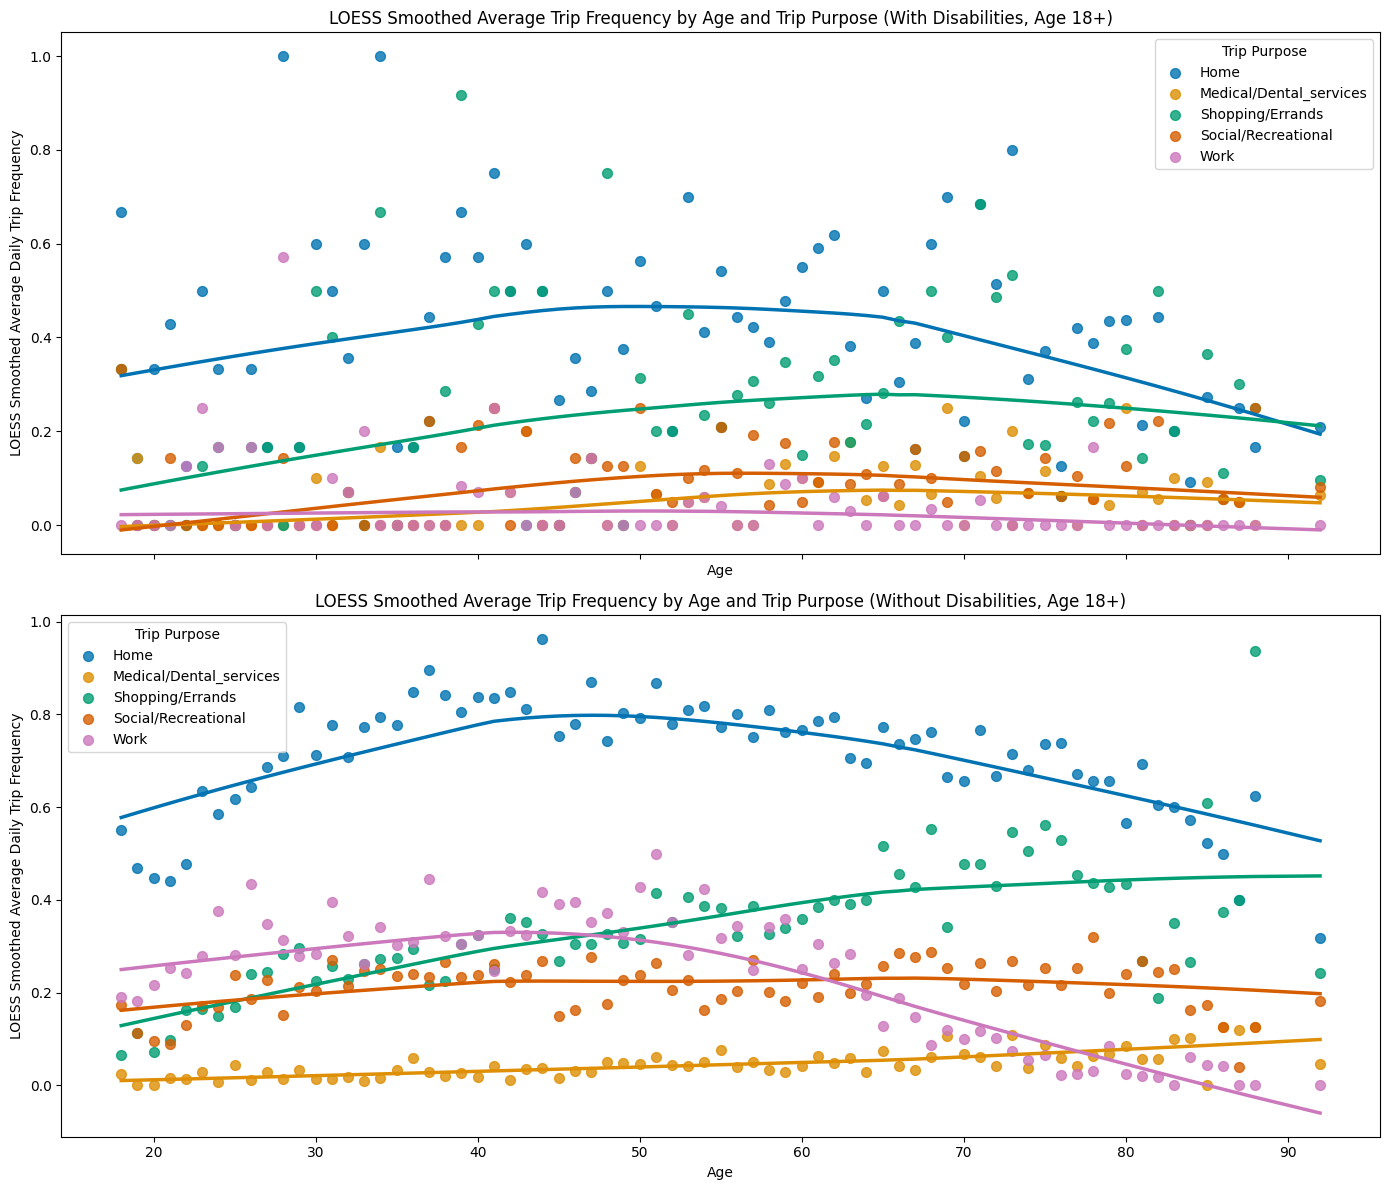

In [290]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




# Assuming zz and ss are your initial DataFrames with raw data
# Filter out individuals younger than 18
zz_filtered = zz[zz['R_AGE'] >= 18]
ss_filtered = ss[ss['R_AGE'] >= 18]

# List the trip purposes you want to include
trip_purposes = [
    'Home', 'Medical/Dental_services', 'Shopping/Errands', 'Social/Recreational', 'Work'
]

# Calculate the average number of trips for each purpose by age for zz (with disabilities)
averages_zz = zz_filtered.groupby('R_AGE')[trip_purposes].mean().reset_index()

# Calculate the average number of trips for each purpose by age for ss (without disabilities)
averages_ss = ss_filtered.groupby('R_AGE')[trip_purposes].mean().reset_index()

# Now let's melt these average DataFrames into long format for plotting
averages_zz_melted = averages_zz.melt(id_vars='R_AGE', var_name='Trip_purpose', value_name='Average_Trips')
averages_ss_melted = averages_ss.melt(id_vars='R_AGE', var_name='Trip_purpose', value_name='Average_Trips')


# Filter out the unwanted trip purposes from the melted DataFrames
excluded_purposes = ['Sth_else', 'Transport_somebody', 'Meals', 'School/Daycare/Religious']
averages_zz_melted_filtered = averages_zz_melted[~averages_zz_melted['Trip_purpose'].isin(excluded_purposes)]
averages_ss_melted_filtered = averages_ss_melted[~averages_ss_melted['Trip_purpose'].isin(excluded_purposes)]


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming averages_zz_melted_filtered and averages_ss_melted_filtered have been defined previously

# Set up the matplotlib figure with subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Define a color palette with only as many colors as there are trip purposes
trip_purposes = [
    'Home', 'Medical/Dental_services', 'Shopping/Errands', 'Social/Recreational', 'Work'
]
strong_palette = sns.color_palette("colorblind", len(trip_purposes))

# Plot for zz (with disabilities) using regplot for LOESS smoothing
for purpose in trip_purposes:
    sns.regplot(ax=axes[0], 
                data=averages_zz_melted_filtered[averages_zz_melted_filtered['Trip_purpose'] == purpose],
                x='R_AGE', y='Average_Trips', 
                label=purpose, scatter_kws={'s': 50}, line_kws={'linewidth': 2.5}, 
                color=strong_palette[trip_purposes.index(purpose)], lowess=True)

axes[0].set_title('LOESS Smoothed Average Trip Frequency by Age and Trip Purpose (With Disabilities, Age 18+)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('LOESS Smoothed Average Daily Trip Frequency')
axes[0].legend(title='Trip Purpose')

# Plot for ss (without disabilities) using regplot for LOESS smoothing
for purpose in trip_purposes:
    sns.regplot(ax=axes[1], 
                data=averages_ss_melted_filtered[averages_ss_melted_filtered['Trip_purpose'] == purpose],
                x='R_AGE', y='Average_Trips', 
                label=purpose, scatter_kws={'s': 50}, line_kws={'linewidth': 2.5},
                color=strong_palette[trip_purposes.index(purpose)], lowess=True)

axes[1].set_title('LOESS Smoothed Average Trip Frequency by Age and Trip Purpose (Without Disabilities, Age 18+)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('LOESS Smoothed Average Daily Trip Frequency')
axes[1].legend(title='Trip Purpose')

# Adjust layout
plt.tight_layout()
plt.show()


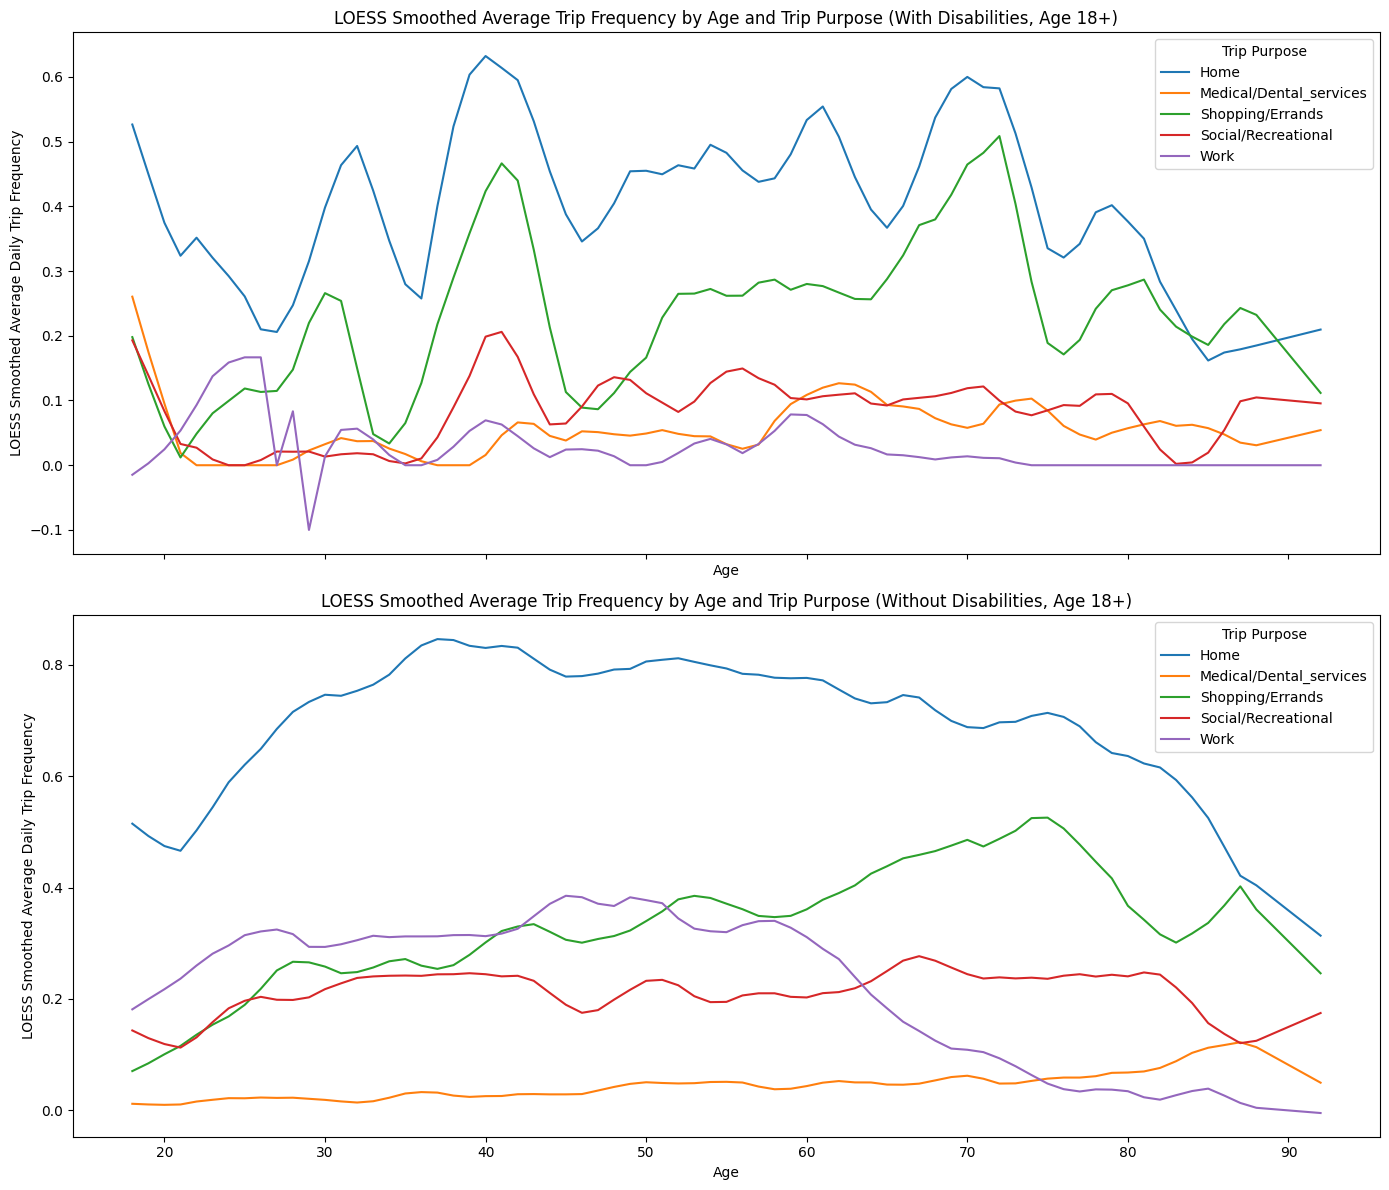

In [291]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


# Assuming zz and ss are your initial DataFrames with raw data
# Filter out individuals younger than 18
zz_filtered = zz[zz['R_AGE'] >= 18]
ss_filtered = ss[ss['R_AGE'] >= 18]

# List the trip purposes you want to include
trip_purposes = [
    'Home', 'Medical/Dental_services', 'Shopping/Errands', 'Social/Recreational', 'Work'
]


# Assuming averages_zz_melted and averages_ss_melted are the DataFrames you want to plot
# and they have been filtered to exclude individuals under 18 and the unwanted trip purposes



# Define the figure and axes
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Define strong color palette with higher saturation
# Make sure the palette has enough colors for your number of trip purposes
strong_palette = sns.color_palette("colorblind", n_colors=len(trip_purposes))

# Function to apply LOWESS smoothing and return smoothed values
def smooth_data(data, x_col, y_col):
    # Sort the data by the x_col to improve the smoothing process
    sorted_data = data.sort_values(by=x_col)
    # Apply LOWESS and return the smoothed y-values
    lowess = sm.nonparametric.lowess
    return lowess(sorted_data[y_col], sorted_data[x_col], frac=0.1)[:, 1]

# Plot for zz (with disabilities)
for purpose in trip_purposes:
    # Filter data for each trip purpose
    df_purpose = averages_zz_melted[averages_zz_melted['Trip_purpose'] == purpose]
    # Apply smoothing
    smoothed_values = smooth_data(df_purpose, 'R_AGE', 'Average_Trips')
    # Plot
    axes[0].plot(df_purpose['R_AGE'], smoothed_values, label=purpose)

axes[0].set_title('LOESS Smoothed Average Trip Frequency by Age and Trip Purpose (With Disabilities, Age 18+)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('LOESS Smoothed Average Daily Trip Frequency')
axes[0].legend(title='Trip Purpose')

# Plot for ss (without disabilities)
for purpose in trip_purposes:
    # Filter data for each trip purpose
    df_purpose = averages_ss_melted[averages_ss_melted['Trip_purpose'] == purpose]
    # Apply smoothing
    smoothed_values = smooth_data(df_purpose, 'R_AGE', 'Average_Trips')
    # Plot
    axes[1].plot(df_purpose['R_AGE'], smoothed_values, label=purpose)

axes[1].set_title('LOESS Smoothed Average Trip Frequency by Age and Trip Purpose (Without Disabilities, Age 18+)')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('LOESS Smoothed Average Daily Trip Frequency')
axes[1].legend(title='Trip Purpose')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


## Variables selection

In [292]:
pp10=pp9.copy()

In [293]:
print(pp10)

       CNTTDTR  HHSIZE  HHVEHCNT  \
0            2       4         2   
1            3       4         2   
2            0       4         2   
3            2       4         2   
4            3       2         1   
...        ...     ...       ...   
16992        0       1         1   
16993        0       2         2   
16994        0       2         2   
16995        0       1         0   
16996        3       1         1   

                                               HOMEOWN SCHOOL1 MEDCOND  R_AGE  \
0             Owned by hh member with mortgage or loan      No      No     39   
1             Owned by hh member with mortgage or loan      No      No     42   
2             Owned by hh member with mortgage or loan     Yes      No      8   
3             Owned by hh member with mortgage or loan     Yes      No      5   
4                                  Rented by hh member      No     Yes     32   
...                                                ...     ...     ...    ...   


In [294]:
pp10.columns

Index(['CNTTDTR', 'HHSIZE', 'HHVEHCNT', 'HOMEOWN', 'SCHOOL1', 'MEDCOND',
       'R_AGE', 'MSACAT', 'NUMADLT', 'R_SEX_IMP', 'R_RACE_IMP', 'HH_HISP',
       'URBAN', 'URBANSIZE', 'WORKER', 'WRKCOUNT', 'DRVRCNT', 'WTPERFIN',
       'DRIVER', 'HOMETYPE', 'PPT517', 'YOUNGCHILD', 'LIF_CYC', 'CENSUS_R',
       'TRAVDAY', 'TDAYDATE', 'HHINC_4Cat', 'EDUC_6cat', 'HOUSEID', 'PERSONID',
       'uid', 'Total_TRPMILES', 'Total_TRVLCMIN', 'Home', 'Meals',
       'Medical/Dental_services', 'School/Daycare/Religious',
       'Shopping/Errands', 'Social/Recreational', 'Sth_else',
       'Transport_somebody', 'Work'],
      dtype='object')

In [295]:
# m_var=['CNTTDTR', 'HHSIZE', 'HHVEHCNT', 'HOMEOWN', 'SCHOOL1', 'MEDCOND',
#   'MSACAT', 'NUMADLT', 'R_SEX_IMP', 'R_RACE_IMP', 'HH_HISP', 'URBAN', 'URBANSIZE', 'WORKER',
#     'WRKCOUNT', 'DRVRCNT', 'WTPERFIN', 'DRIVER', 'HOMETYPE', 'PPT517', 'YOUNGCHILD', 'LIF_CYC',
#       'CENSUS_R', 'TRAVDAY', 'TDAYDATE', 'HHINC_4Cat', 'EDUC_6cat','HOUSEID','PERSONID']
vv=pp10[['HHSIZE', 'HHVEHCNT', 'HOMEOWN', 'SCHOOL1', 'MEDCOND',
  'MSACAT', 'NUMADLT', 'R_SEX_IMP', 'R_RACE_IMP', 'HH_HISP', 'URBAN', 'URBANSIZE', 'WORKER',
    'WRKCOUNT', 'DRVRCNT', 'DRIVER', 'HOMETYPE', 'PPT517', 'YOUNGCHILD', 'LIF_CYC',
      'CENSUS_R', 'HHINC_4Cat', 'EDUC_6cat']]
# weight_var=pp6[['WTPERFIN']]
# dep_var=pp6[['CNTTDTR']]
# dep_var_cat=[['CNTTDTR_cat_ordered']]


In [296]:
vv.dtypes

HHSIZE           int64
HHVEHCNT         int64
HOMEOWN       category
SCHOOL1       category
MEDCOND       category
MSACAT        category
NUMADLT          int64
R_SEX_IMP     category
R_RACE_IMP    category
HH_HISP       category
URBAN         category
URBANSIZE     category
WORKER        category
WRKCOUNT         int64
DRVRCNT          int64
DRIVER        category
HOMETYPE      category
PPT517           int64
YOUNGCHILD       int64
LIF_CYC       category
CENSUS_R      category
HHINC_4Cat    category
EDUC_6cat     category
dtype: object

In [297]:
# vv=pp9[['CNTTDTR', 'HHSIZE', 'HHVEHCNT', 'HOMEOWN', 'SCHOOL1', 'MEDCOND',
#        'R_AGE', 'MSACAT', 'NUMADLT', 'R_SEX_IMP', 'R_RACE_IMP', 'HH_HISP',
#        'URBAN', 'URBANSIZE', 'WORKER', 'WRKCOUNT', 'DRVRCNT', 'WTPERFIN',
#        'DRIVER', 'HOMETYPE', 'PPT517', 'YOUNGCHILD', 'LIF_CYC', 'CENSUS_R',
#        'TRAVDAY', 'TDAYDATE', 'HHINC_4Cat', 'EDUC_6cat', 'HOUSEID', 'PERSONID',
#        'uid', 'Total_TRPMILES', 'Total_TRVLCMIN', 'Home', 'Meals',
#        'Medical/Dental_services', 'School/Daycare/Religious',
#        'Shopping/Errands', 'Social/Recreational', 'Sth_else',
#        'Transport_somebody', 'Work']]

In [298]:
# 'PPT517' : 'Count of household members 5-17 years old',
#     'YOUNGCHILD' : 'Count of household members under 5 years old',

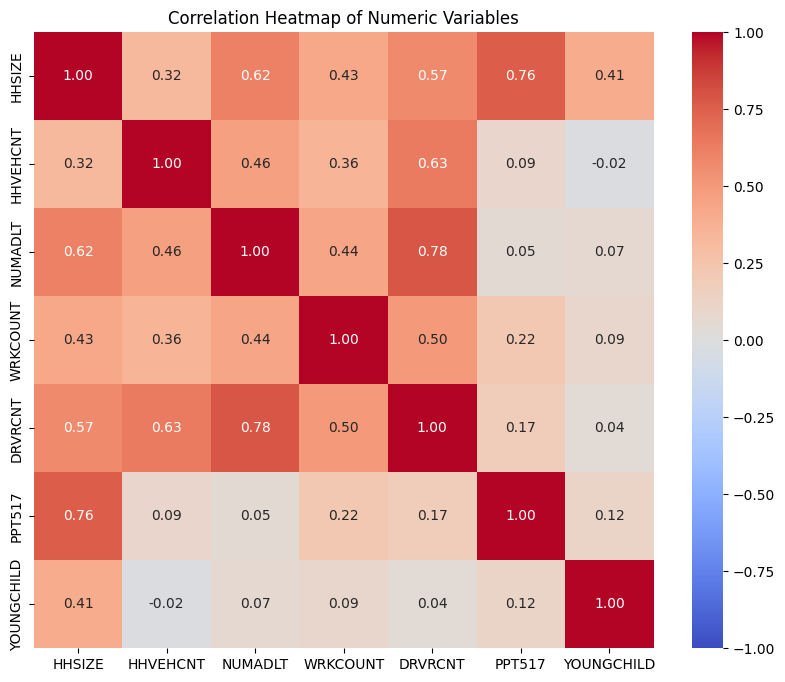

In [299]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'vv' is your DataFrame
# First, select only the numeric columns from 'vv'
numeric_vv = vv.select_dtypes(include=['int64', 'float64'])

# Compute the correlation matrix
corr_matrix = numeric_vv.corr()

# Generate a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()


In [300]:
# Removing DRVRCNT,  HHSIZE

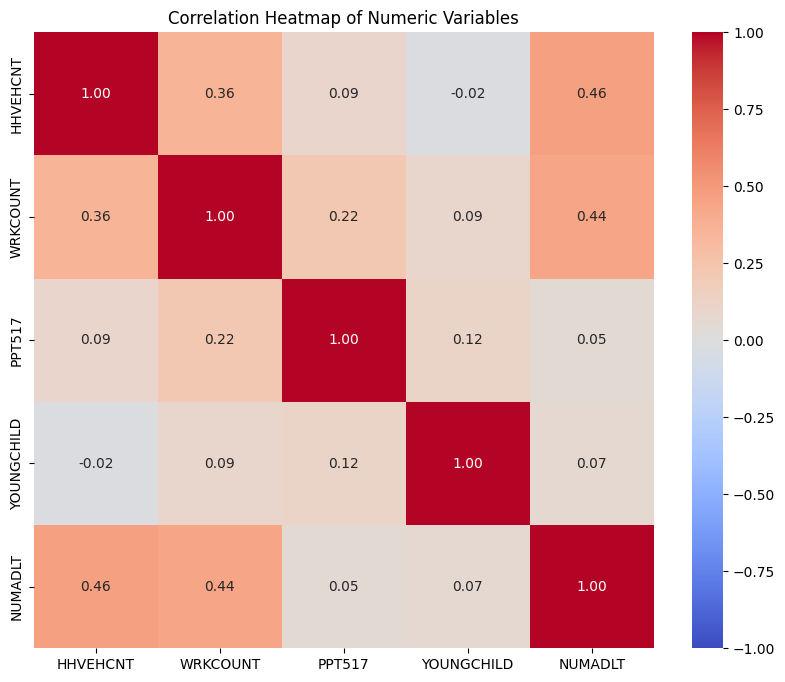

In [301]:
#selected variables ['HHVEHCNT', 'WRKCOUNT','PPT517','YOUNGCHILD','NUMADLT' ]

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

vv2=vv[['HHVEHCNT', 'WRKCOUNT','PPT517','YOUNGCHILD','NUMADLT' ]]
# Assuming 'vv' is your DataFrame
# First, select only the numeric columns from 'vv'
numeric_vv = vv2.select_dtypes(include=['int64', 'float64'])

# Compute the correlation matrix
corr_matrix = numeric_vv.corr()

# Generate a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()


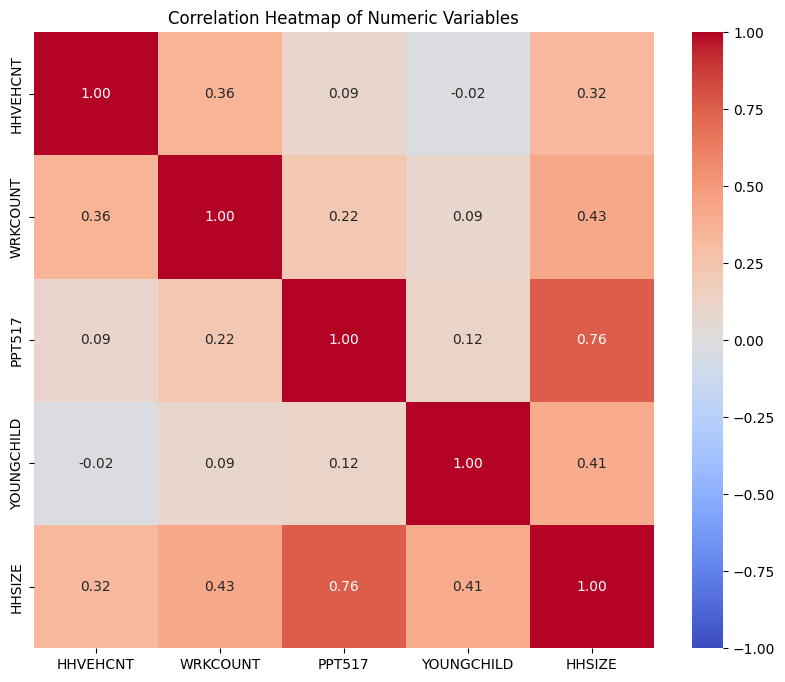

In [302]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

vv2=vv[['HHVEHCNT', 'WRKCOUNT','PPT517','YOUNGCHILD','HHSIZE' ]]
# Assuming 'vv' is your DataFrame
# First, select only the numeric columns from 'vv'
numeric_vv = vv2.select_dtypes(include=['int64', 'float64'])

# Compute the correlation matrix
corr_matrix = numeric_vv.corr()

# Generate a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()


# VIF

In [303]:
# First, select only the numeric columns from 'vv'
cat_vv = vv.select_dtypes(include=['category'])
cat_vv.columns

Index(['HOMEOWN', 'SCHOOL1', 'MEDCOND', 'MSACAT', 'R_SEX_IMP', 'R_RACE_IMP',
       'HH_HISP', 'URBAN', 'URBANSIZE', 'WORKER', 'DRIVER', 'HOMETYPE',
       'LIF_CYC', 'CENSUS_R', 'HHINC_4Cat', 'EDUC_6cat'],
      dtype='object')

In [304]:
var_dif=vv[['HHVEHCNT', 'WRKCOUNT','PPT517','YOUNGCHILD','NUMADLT',
    'HOMEOWN', 'SCHOOL1', 'MEDCOND', 'MSACAT', 'R_SEX_IMP', 'R_RACE_IMP',
       'HH_HISP', 'URBAN', 'URBANSIZE', 'WORKER', 'DRIVER', 'HOMETYPE',
       'LIF_CYC', 'CENSUS_R', 'HHINC_4Cat', 'EDUC_6cat' ]]

In [305]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder

# Selecting the numerical data from 'vv' DataFrame
numerical_data = vv[['HHVEHCNT', 'WRKCOUNT','PPT517','YOUNGCHILD','NUMADLT']]

# Listing the categorical variables
categorical_variables = ['HOMEOWN', 'SCHOOL1', 'MEDCOND', 'MSACAT', 'R_SEX_IMP', 'R_RACE_IMP',
                         'HH_HISP', 'URBAN', 'URBANSIZE', 'WORKER', 'DRIVER', 'HOMETYPE',
                         'LIF_CYC', 'CENSUS_R', 'HHINC_4Cat', 'EDUC_6cat']

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode categorical variables using LabelEncoder to keep them as single variables
categorical_data_encoded = vv[categorical_variables].apply(lambda col: label_encoder.fit_transform(col.astype(str)))

# Combine the label-encoded categorical data with the numerical data
combined_data = pd.concat([categorical_data_encoded, numerical_data], axis=1)

# Calculate VIF for the combined dataset to avoid dummy variable trap
vif_data = pd.DataFrame()
vif_data['Variable'] = combined_data.columns
vif_data['VIF'] = [variance_inflation_factor(combined_data.values, i)
                   for i in range(combined_data.shape[1])]

vif_data


,Variable,VIF
0,HOMEOWN,9.062272
1,SCHOOL1,2.138220
2,MEDCOND,12.392183
3,MSACAT,2.197953
4,R_SEX_IMP,1.962144
5,R_RACE_IMP,12.018757
6,HH_HISP,10.393522
7,URBAN,8.142989
8,URBANSIZE,3.288807
9,WORKER,4.842417


In [306]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder

# Selecting the numerical data from 'vv' DataFrame
numerical_data = vv[['HHVEHCNT', 'WRKCOUNT','PPT517','YOUNGCHILD']]

# Listing the categorical variables
categorical_variables = [ 'SCHOOL1',  'MSACAT', 'R_SEX_IMP', 
                         'URBANSIZE', 'WORKER',
                         'LIF_CYC', 'CENSUS_R', 'HHINC_4Cat', 'EDUC_6cat']

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode categorical variables using LabelEncoder to keep them as single variables
categorical_data_encoded = vv[categorical_variables].apply(lambda col: label_encoder.fit_transform(col.astype(str)))

# Combine the label-encoded categorical data with the numerical data
combined_data = pd.concat([categorical_data_encoded, numerical_data], axis=1)

# Calculate VIF for the combined dataset to avoid dummy variable trap
vif_data = pd.DataFrame()
vif_data['Variable'] = combined_data.columns
vif_data['VIF'] = [variance_inflation_factor(combined_data.values, i)
                   for i in range(combined_data.shape[1])]

vif_data

,Variable,VIF
0,SCHOOL1,1.970822
1,MSACAT,1.948585
2,R_SEX_IMP,1.881232
3,URBANSIZE,2.734238
4,WORKER,4.090893
5,LIF_CYC,2.587997
6,CENSUS_R,2.701925
7,HHINC_4Cat,2.711049
8,EDUC_6cat,2.781448
9,HHVEHCNT,4.779892


## Negative Binomial

In [309]:
pp10.columns

Index(['CNTTDTR', 'HHSIZE', 'HHVEHCNT', 'HOMEOWN', 'SCHOOL1', 'MEDCOND',
       'R_AGE', 'MSACAT', 'NUMADLT', 'R_SEX_IMP', 'R_RACE_IMP', 'HH_HISP',
       'URBAN', 'URBANSIZE', 'WORKER', 'WRKCOUNT', 'DRVRCNT', 'WTPERFIN',
       'DRIVER', 'HOMETYPE', 'PPT517', 'YOUNGCHILD', 'LIF_CYC', 'CENSUS_R',
       'TRAVDAY', 'TDAYDATE', 'HHINC_4Cat', 'EDUC_6cat', 'HOUSEID', 'PERSONID',
       'uid', 'Total_TRPMILES', 'Total_TRVLCMIN', 'Home', 'Meals',
       'Medical/Dental_services', 'School/Daycare/Religious',
       'Shopping/Errands', 'Social/Recreational', 'Sth_else',
       'Transport_somebody', 'Work'],
      dtype='object')

In [ ]:
#For People without disabilities
nn=ss[['HHVEHCNT', 'WRKCOUNT','PPT517','YOUNGCHILD']]
cc=ss[[ 'SCHOOL1',  'MSACAT', 'R_SEX_IMP', 
                         'URBANSIZE', 'WORKER',
                         'LIF_CYC', 'CENSUS_R', 'HHINC_4Cat', 'EDUC_6cat']]
dep=ss[['CNTTDTR']]
n_weight=ss[['WTPERFIN']]

In [ ]:
# # Filter rows where 'MEDCOND' is not 'Yes'
# ss = pp9[pp9['MEDCOND'] != 'Yes']
# print(ss)

In [ ]:
# zz PWDs
# ss healthy

# for healthy Negative Binomial Regression

In [325]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Prepare the data
nn = ss[['HHVEHCNT', 'WRKCOUNT', 'PPT517', 'YOUNGCHILD']]
#cc = ss[['SCHOOL1', 'MSACAT', 'R_SEX_IMP', 'URBANSIZE', 'WORKER', 'LIF_CYC', 'CENSUS_R', 'HHINC_4Cat', 'EDUC_6cat']]
cc = ss[[ 'R_SEX_IMP', 'HHINC_4Cat', 'EDUC_6cat', 'WORKER', 'SCHOOL1', 'LIF_CYC', 'MSACAT', 'URBANSIZE', 'CENSUS_R']]
dep = ss[['CNTTDTR']]
n_weight = ss[['WTPERFIN']]

# Initialize the OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse=False)

# Assuming 'cc' is your categorical data and 'nn' your numerical data
categorical_data = cc
numerical_data = nn

# Fit and transform the categorical data
categorical_encoded = encoder.fit_transform(categorical_data)
categorical_encoded_df = pd.DataFrame(categorical_encoded, columns=encoder.get_feature_names_out(categorical_data.columns))

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical data
numerical_scaled = scaler.fit_transform(numerical_data)
numerical_scaled_df = pd.DataFrame(numerical_scaled, columns=numerical_data.columns)

# Combine the processed categorical and numerical dataframes
#processed_df = pd.concat([categorical_encoded_df, numerical_scaled_df], axis=1)
processed_df = pd.concat([numerical_scaled_df, categorical_encoded_df], axis=1)

# Define X (independent variables) and y (dependent variable)
X = processed_df
y = dep.squeeze()  # Assuming 'dep' is your dependent variable dataframe

# Initialize k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = []
mae_scores = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    # Split the data into training and testing sets
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Reset the index to ensure alignment
    X_train = X_train.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)
    
    # Add a constant to the model (intercept)
    X_train_const = sm.add_constant(X_train)
    X_test_const = sm.add_constant(X_test)
    
    # Fit a Negative Binomial regression model
    #nb_model = NegativeBinomial(y_train, X_train_const, weights=n_weight.iloc[train_index]).fit(maxiter=100)
    nb_model = NegativeBinomial(y_train, X_train_const).fit(maxiter=100)

    # Print the summary for the first fold only
    if i == 0:
        print("Summary for the first fold:")
        print(nb_model.summary())  
    
    # Generate predictions for the test set
    y_pred = nb_model.predict(X_test_const)
    
    # Calculate and store RMSE and MAE for each fold
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae_scores.append(mean_absolute_error(y_test, y_pred))



# Calculate average RMSE and MAE across all folds
avg_rmse = np.mean(rmse_scores)
avg_mae = np.mean(mae_scores)

# Print average RMSE and MAE
print(f"Average RMSE: {avg_rmse}")
print(f"Average MAE: {avg_mae}")


Optimization terminated successfully.
         Current function value: 1.817875
         Iterations: 78
         Function evaluations: 79
         Gradient evaluations: 79
Summary for the first fold:
                     NegativeBinomial Regression Results                      
Dep. Variable:                CNTTDTR   No. Observations:                12632
Model:               NegativeBinomial   Df Residuals:                    12594
Method:                           MLE   Df Model:                           37
Date:                Tue, 27 Feb 2024   Pseudo R-squ.:                 0.01756
Time:                        00:15:42   Log-Likelihood:                -22963.
converged:                       True   LL-Null:                       -23374.
Covariance Type:            nonrobust   LLR p-value:                2.326e-148
                                                     coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------

For PWDS

In [327]:
#For People with disabilities

nnn = zz[['HHVEHCNT', 'WRKCOUNT', 'PPT517', 'YOUNGCHILD']]
ccc = zz[[ 'R_SEX_IMP', 'HHINC_4Cat', 'EDUC_6cat', 'WORKER', 'SCHOOL1', 'LIF_CYC', 'MSACAT', 'URBANSIZE', 'CENSUS_R']]

dep2=zz[['CNTTDTR']]
n_weight=zz[['WTPERFIN']]

In [328]:
#For People with disabilities
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Prepare the data
nnn = zz[['HHVEHCNT', 'WRKCOUNT', 'PPT517', 'YOUNGCHILD']]
ccc = zz[[ 'R_SEX_IMP', 'HHINC_4Cat', 'EDUC_6cat', 'WORKER', 'SCHOOL1', 'LIF_CYC', 'MSACAT', 'URBANSIZE', 'CENSUS_R']]

dep2=zz[['CNTTDTR']]
n_weight=zz[['WTPERFIN']]

# Initialize the OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse=False)

# Assuming 'cc' is your categorical data and 'nn' your numerical data
categorical_data = ccc
numerical_data = nnn

# Fit and transform the categorical data
categorical_encoded = encoder.fit_transform(categorical_data)
categorical_encoded_df = pd.DataFrame(categorical_encoded, columns=encoder.get_feature_names_out(categorical_data.columns))

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical data
numerical_scaled = scaler.fit_transform(numerical_data)
numerical_scaled_df = pd.DataFrame(numerical_scaled, columns=numerical_data.columns)

# Combine the processed categorical and numerical dataframes
#processed_df = pd.concat([categorical_encoded_df, numerical_scaled_df], axis=1)
processed_df = pd.concat([numerical_scaled_df, categorical_encoded_df], axis=1)

# Define X (independent variables) and y (dependent variable)
X = processed_df
y = dep2.squeeze()  # Assuming 'dep2' is your dependent variable dataframe

# Initialize k-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = []
mae_scores = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    # Split the data into training and testing sets
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Reset the index to ensure alignment
    X_train = X_train.reset_index(drop=True)
    X_test = X_test.reset_index(drop=True)
    y_train = y_train.reset_index(drop=True)
    y_test = y_test.reset_index(drop=True)
    
    # Add a constant to the model (intercept)
    X_train_const = sm.add_constant(X_train)
    X_test_const = sm.add_constant(X_test)
    
    # Fit a Negative Binomial regression model
    #nb_model = NegativeBinomial(y_train, X_train_const, weights=n_weight.iloc[train_index]).fit(maxiter=100)
    nb_model = NegativeBinomial(y_train, X_train_const).fit(maxiter=100)

    # Print the summary for the first fold only
    if i == 0:
        print("Summary for the first fold:")
        print(nb_model.summary())  
    
    # Generate predictions for the test set
    y_pred = nb_model.predict(X_test_const)
    
    # Calculate and store RMSE and MAE for each fold
    rmse_scores.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae_scores.append(mean_absolute_error(y_test, y_pred))



# Calculate average RMSE and MAE across all folds
avg_rmse = np.mean(rmse_scores)
avg_mae = np.mean(mae_scores)

# Print average RMSE and MAE
print(f"Average RMSE: {avg_rmse}")
print(f"Average MAE: {avg_mae}")

         Current function value: 1.400049
         Iterations: 100
         Function evaluations: 101
         Gradient evaluations: 101
Summary for the first fold:
                     NegativeBinomial Regression Results                      
Dep. Variable:                CNTTDTR   No. Observations:                  964
Model:               NegativeBinomial   Df Residuals:                      927
Method:                           MLE   Df Model:                           36
Date:                Tue, 27 Feb 2024   Pseudo R-squ.:                 0.02606
Time:                        08:56:03   Log-Likelihood:                -1349.6
converged:                      False   LL-Null:                       -1385.8
Covariance Type:            nonrobust   LLR p-value:                 0.0003201
                                                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

i:\ProgramData\Anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 1.427034
         Iterations: 100
         Function evaluations: 101
         Gradient evaluations: 101


i:\ProgramData\Anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 1.380579
         Iterations: 100
         Function evaluations: 101
         Gradient evaluations: 101


i:\ProgramData\Anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 1.380919
         Iterations: 100
         Function evaluations: 101
         Gradient evaluations: 101


i:\ProgramData\Anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 1.416660
         Iterations: 100
         Function evaluations: 101
         Gradient evaluations: 101
Average RMSE: 1.6659498897678717
Average MAE: 1.290699019354723


i:\ProgramData\Anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
